# Final Exam BUS 458 — Loan Data Analysis
**Objective:** Your objective is to identify the key drivers of loan approval and recommend which lender should be prioritized for each customer to maximize total payout

### **Instructions**
- Follow the prompts in each section of this notebook.
- **Where you see a “Question,” answer it directly below in a Markdown (text) cell — not as a code comment.**
- Your **reasoning, interpretations, and insights** should be written in text cells, clearly separated from code.
- You are encouraged to add extra **code cells**, **visualizations**, or **short explanations** if they strengthen your analysis or help you justify decisions.
- Make sure your notebook runs cleanly from start to finish without errors.


In [417]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Data (via Google Drive or direct upload)

In [418]:
df = pd.read_csv('loan_data_analysis_final.csv')

In [419]:
# Check first 5 rows of dataframe
df.head(5)

,User ID,applications,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,00007820-89cb-4c1d-9940-eb270d605a35,1,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,00012b55-514c-421e-9c76-3300abbc1134,1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,000157c1-b6a3-4c86-82c7-9ec1bda3799a,1,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,00020400-efab-4b10-8812-2a0aaf774841,1,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,0002f737-0cda-48fb-91ed-533f3d0eab05,1,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


In [420]:
# Drop columns that have no variation or are unique
# Check which columns have low/no variation
df.nunique()

User ID                       100000
applications                       1
Reason                             6
Granted_Loan_Amount               12
Requested_Loan_Amount            459
FICO_score                       551
Fico_Score_group                   5
Employment_Status                  3
Employment_Sector                 11
Monthly_Gross_Income           12330
Monthly_Housing_Payment         3002
Ever_Bankrupt_or_Foreclose         2
Lender                             3
Approved                           2
bounty                             4
dtype: int64

In [421]:
# Drop the columns
df = df.drop(columns=['User ID', 'applications'], errors='ignore')

df.head()

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
0,cover_an_unexpected_cost,100000,123000.0,669.0,fair,full_time,consumer_discretionary,5024.0,927,0,B,0,0
1,credit_card_refinancing,70000,79000.0,594.0,fair,full_time,information_technology,5764.0,1177,0,B,0,0
2,home_improvement,10000,11000.0,596.0,fair,full_time,information_technology,4017.0,1487,0,A,0,0
3,home_improvement,100000,120000.0,642.0,fair,part_time,energy,3129.0,904,0,A,0,0
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0


Understand the Data: Get a quick overview of the dataset structure and variable meanings before preprocessing.

In [422]:
df.info()

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  str    
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  85000 non-null   float64
 4   Fico_Score_group            100000 non-null  str    
 5   Employment_Status           100000 non-null  str    
 6   Employment_Sector           93593 non-null   str    
 7   Monthly_Gross_Income        85000 non-null   float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  str    
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtypes: float64(3), int64(5), s

,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Approved,bounty
count,1.000000e+05,1.000000e+05,85000.000000,85000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.478465e+04,7.450309e+04,629.338153,5808.783776,1888.900720,0.022460,0.109760,26.415000
std,1.965837e+05,2.264856e+05,88.684201,2988.185274,3431.924282,0.148175,0.312592,78.385644
min,5.000000e+03,5.000000e+03,300.000000,-17702.000000,300.000000,0.000000,0.000000,0.000000
25%,2.000000e+04,2.400000e+04,572.000000,3659.000000,1231.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,4.400000e+04,634.000000,5153.500000,1669.000000,0.000000,0.000000,0.000000
75%,7.000000e+04,8.400000e+04,693.000000,7612.000000,2051.000000,0.000000,0.000000,0.000000
max,2.000000e+06,2.500000e+06,850.000000,19997.000000,49500.000000,1.000000,1.000000,350.000000


## 1. Preprocessing


### 1.1 Handling Missing Values

**Question:** Why is median imputation often preferable to mean imputation for income and FICO?


**Answer:** Using the median is more resistant to outliers, which in the case of income can greatly affect the model's performance if outliers are included in the imputation.





In [423]:
# Inspect missing values
df[df.isnull().any(axis=1)]

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty
4,major_purchase,30000,34000.0,NaN,fair,full_time,energy,NaN,1620,0,A,0,0
6,other,80000,89000.0,691.0,good,full_time,communication_services,NaN,1289,0,A,1,250
19,credit_card_refinancing,10000,11000.0,682.0,good,full_time,industrials,NaN,2372,0,B,0,0
20,other,20000,23000.0,605.0,fair,full_time,materials,NaN,2326,0,B,0,0
21,other,10000,12000.0,721.0,good,full_time,health_care,NaN,2495,0,B,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99991,credit_card_refinancing,30000,32000.0,701.0,good,full_time,real_estate,NaN,1376,0,A,1,250
99995,other,40000,50000.0,NaN,good,full_time,consumer_staples,5800.0,1460,0,A,0,0
99997,major_purchase,80000,96000.0,NaN,poor,full_time,real_estate,3312.0,1210,0,C,0,0
99998,debt_conslidation,90000,109000.0,NaN,poor,full_time,industrials,4597.0,1420,0,C,0,0


In [424]:
%%sql
select Fico_Score, Fico_Score_group from df where Fico_Score is null;

,FICO_score,Fico_Score_group
0,NaN,fair
1,NaN,poor
2,NaN,good
3,NaN,fair
4,NaN,poor
...,...,...
14995,NaN,fair
14996,NaN,good
14997,NaN,poor
14998,NaN,poor


In [425]:
# Apply imputation as instructed in the instructions pdf (create copies so original rows can be restored if needed)

# Keep an untouched copy of the original data
df_original = df.copy()

# Create a working copy for imputation
df_imputed = df.copy()

# Impute FICO_score using the median of the corresponding Fico_Score_group
# Does not make sense to impute with the overall median since the Fico_Score_Group tells us the range of the possible credit score
fico_group_medians = df_imputed.groupby('Fico_Score_group')['FICO_score'].median()

df_imputed['FICO_score'] = df_imputed['FICO_score'].fillna(
    df_imputed['Fico_Score_group'].map(fico_group_medians)
)

# Impute Monthly_Gross_Income with the overall median
monthly_income_median = df_imputed['Monthly_Gross_Income'].median()
df_imputed['Monthly_Gross_Income'] = df_imputed['Monthly_Gross_Income'].fillna(monthly_income_median)

# Impute Employment_Sector with "Unkown"
df_imputed['Employment_Sector'] = df_imputed['Employment_Sector'].fillna("Unkown")

# Update df to the imputed version for downstream steps
df = df_imputed.copy()

df.info()

df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Reason                      100000 non-null  str    
 1   Granted_Loan_Amount         100000 non-null  int64  
 2   Requested_Loan_Amount       100000 non-null  float64
 3   FICO_score                  100000 non-null  float64
 4   Fico_Score_group            100000 non-null  str    
 5   Employment_Status           100000 non-null  str    
 6   Employment_Sector           100000 non-null  str    
 7   Monthly_Gross_Income        100000 non-null  float64
 8   Monthly_Housing_Payment     100000 non-null  int64  
 9   Ever_Bankrupt_or_Foreclose  100000 non-null  int64  
 10  Lender                      100000 non-null  str    
 11  Approved                    100000 non-null  int64  
 12  bounty                      100000 non-null  int64  
dtypes: float64(3), int64(5), s

,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Approved,bounty
count,1.000000e+05,1.000000e+05,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000
mean,6.478465e+04,7.450309e+04,630.588790,5710.49121,1888.900720,0.022460,0.109760,26.415000
std,1.965837e+05,2.264856e+05,86.154851,2764.88676,3431.924282,0.148175,0.312592,78.385644
min,5.000000e+03,5.000000e+03,300.000000,-17702.00000,300.000000,0.000000,0.000000,0.000000
25%,2.000000e+04,2.400000e+04,570.000000,4053.00000,1231.000000,0.000000,0.000000,0.000000
50%,4.000000e+04,4.400000e+04,628.000000,5153.50000,1669.000000,0.000000,0.000000,0.000000
75%,7.000000e+04,8.400000e+04,698.000000,7123.00000,2051.000000,0.000000,0.000000,0.000000
max,2.000000e+06,2.500000e+06,850.000000,19997.00000,49500.000000,1.000000,1.000000,350.000000


### 1.2 Outliers Detection and Removal

**Question:**
Which features had the most outliers, and what impact could they have on the model?

**Answer** : Requested Loan Amount and Mothly Gross Income had the most outliers. Including these in the model can sway the prediction of the model and thus decrease its effectiveness.

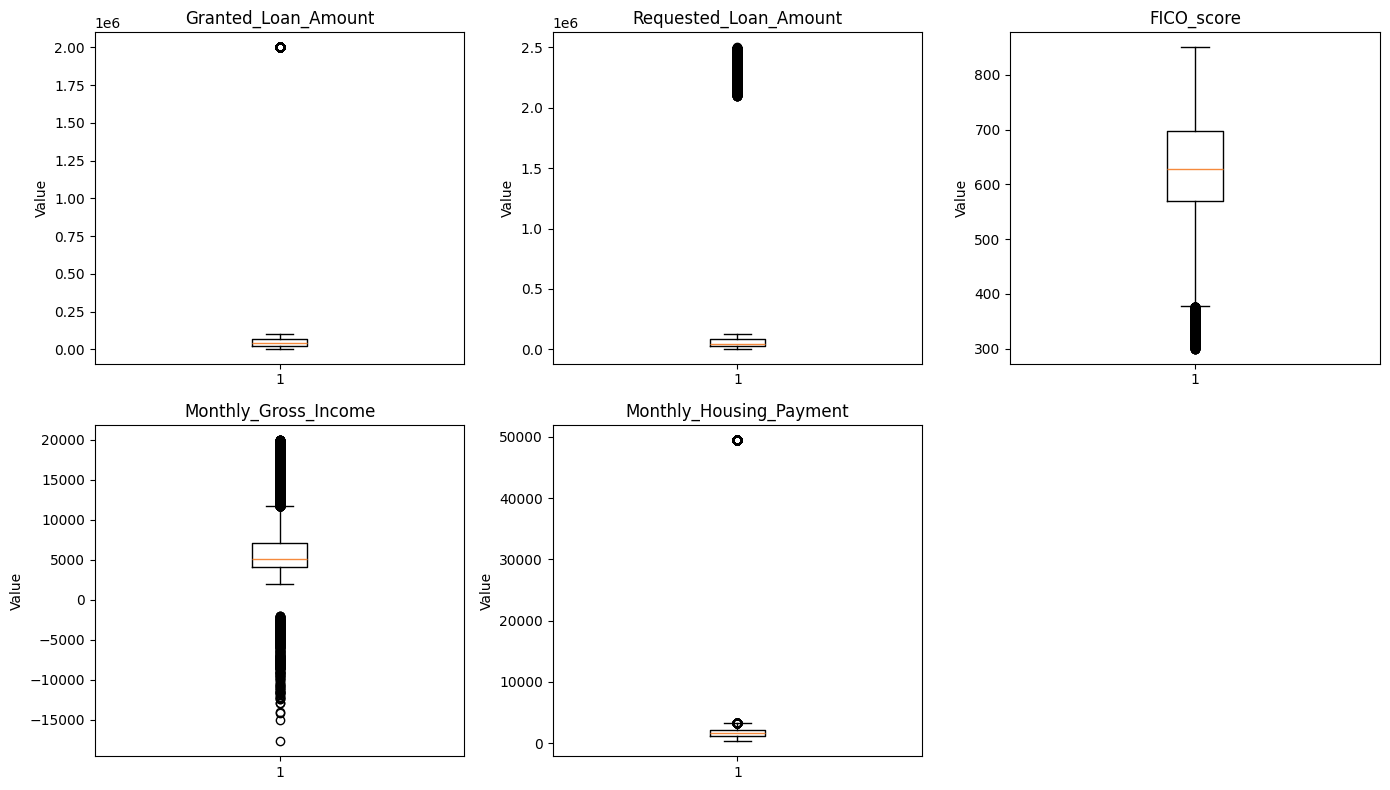

In [426]:
# Boxplots to highlight outliers for numerical columns
numeric_cols = ['Granted_Loan_Amount', 'Requested_Loan_Amount','FICO_score','Monthly_Gross_Income','Monthly_Housing_Payment']

plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[col].dropna(), vert=True)
    plt.title(col)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()


In [427]:
# Isolate numeric columns and calculate skewness
numeric_skews = df.select_dtypes(include=['number']).skew().sort_values(ascending=False)

# Filter for columns with significant right-skew (typically > 1)
high_skew_cols = numeric_skews[numeric_skews > 1]

print("Columns recommended for Log Transformation (Skew > 1):")
print(high_skew_cols)

print("\nAll numeric skewness values:")
print(numeric_skews)

Columns recommended for Log Transformation (Skew > 1):
Monthly_Housing_Payment       13.343826
Requested_Loan_Amount          9.571475
Granted_Loan_Amount            9.534390
Ever_Bankrupt_or_Foreclose     6.445760
bounty                         2.861448
Approved                       2.496851
dtype: float64

All numeric skewness values:
Monthly_Housing_Payment       13.343826
Requested_Loan_Amount          9.571475
Granted_Loan_Amount            9.534390
Ever_Bankrupt_or_Foreclose     6.445760
bounty                         2.861448
Approved                       2.496851
Monthly_Gross_Income           0.886116
FICO_score                    -0.367822
dtype: float64


In [428]:
# Create Log DF for model training

import numpy as np

# Create a copy so you don't overwrite your original data
df_logged = df.copy()

def add_engineered_features(df):
    # Adding a tiny value (epsilon) to denominators to prevent division-by-zero errors
    # if any applicant happens to have exactly 0 for income or FICO
    epsilon = 1e-9

    # 1. Debt-to-Income Ratio (DTI)
    df['DTI'] = df['Monthly_Housing_Payment'] / (df['Monthly_Gross_Income'] + epsilon)

    # 2. Loan-to-Income Ratio (using annualized income)
    df['Loan_to_Income_Ratio'] = df['Requested_Loan_Amount'] / ((df['Monthly_Gross_Income'] * 12) + epsilon)

    # 3. Monthly Disposable Income
    df['Monthly_Disposable_Income'] = df['Monthly_Gross_Income'] - df['Monthly_Housing_Payment']

    # 4. Loan to Fico score ratio
    df['Loan_to_Fico_Ratio'] = df['Requested_Loan_Amount'] / (df['FICO_score'] + epsilon)

    return df

df_logged = add_engineered_features(df_logged)

# Apply log transformation to the high-skew columns you identified
# Replace these with the actual column names from your skewness check
cols_to_log = ['Monthly_Housing_Payment','Requested_Loan_Amount','Granted_Loan_Amount']

for col in cols_to_log:
    df_logged[col] = np.log1p(df_logged[col])

df_logged.head()

,Reason,Granted_Loan_Amount,Requested_Loan_Amount,FICO_score,Fico_Score_group,Employment_Status,Employment_Sector,Monthly_Gross_Income,Monthly_Housing_Payment,Ever_Bankrupt_or_Foreclose,Lender,Approved,bounty,DTI,Loan_to_Income_Ratio,Monthly_Disposable_Income,Loan_to_Fico_Ratio
0,cover_an_unexpected_cost,11.512935,11.719948,669.0,fair,full_time,consumer_discretionary,5024.0,6.833032,0,B,0,0,0.184514,2.040207,4097.0,183.856502
1,credit_card_refinancing,11.156265,11.277216,594.0,fair,full_time,information_technology,5764.0,7.071573,0,B,0,0,0.204198,1.142147,4587.0,132.996633
2,home_improvement,9.210440,9.305741,596.0,fair,full_time,information_technology,4017.0,7.305188,0,A,0,0,0.370177,0.228197,2530.0,18.456376
3,home_improvement,11.512935,11.695255,642.0,fair,part_time,energy,3129.0,6.807935,0,A,0,0,0.288910,3.195909,2225.0,186.915888
4,major_purchase,10.308986,10.434145,626.0,fair,full_time,energy,5153.5,7.390799,0,A,0,0,0.314349,0.549788,3533.5,54.313099


In [429]:
# Remove Outliers using Z-score

from scipy import stats
import numpy as np

# Compute Z-scores for only numeric columns
z_scores = np.abs(stats.zscore(df[numeric_cols], nan_policy='omit'))

# Choose threshold
threshold = 3  # common choice: 3 standard deviations

# Identify rows to keep (all Z-scores <= threshold)
rows_to_keep = (z_scores < threshold).all(axis=1)

# Track counts before/after
before_count = df.shape[0]
df_clean = df[rows_to_keep].copy()
after_count = df_clean.shape[0]

print(f"Outlier removal complete:")
print(f"Rows before: {before_count}")
print(f"Rows after:  {after_count}")
print(f"Rows removed: {before_count - after_count}")

df_clean = add_engineered_features(df_clean)



Outlier removal complete:
Rows before: 100000
Rows after:  95943
Rows removed: 4057


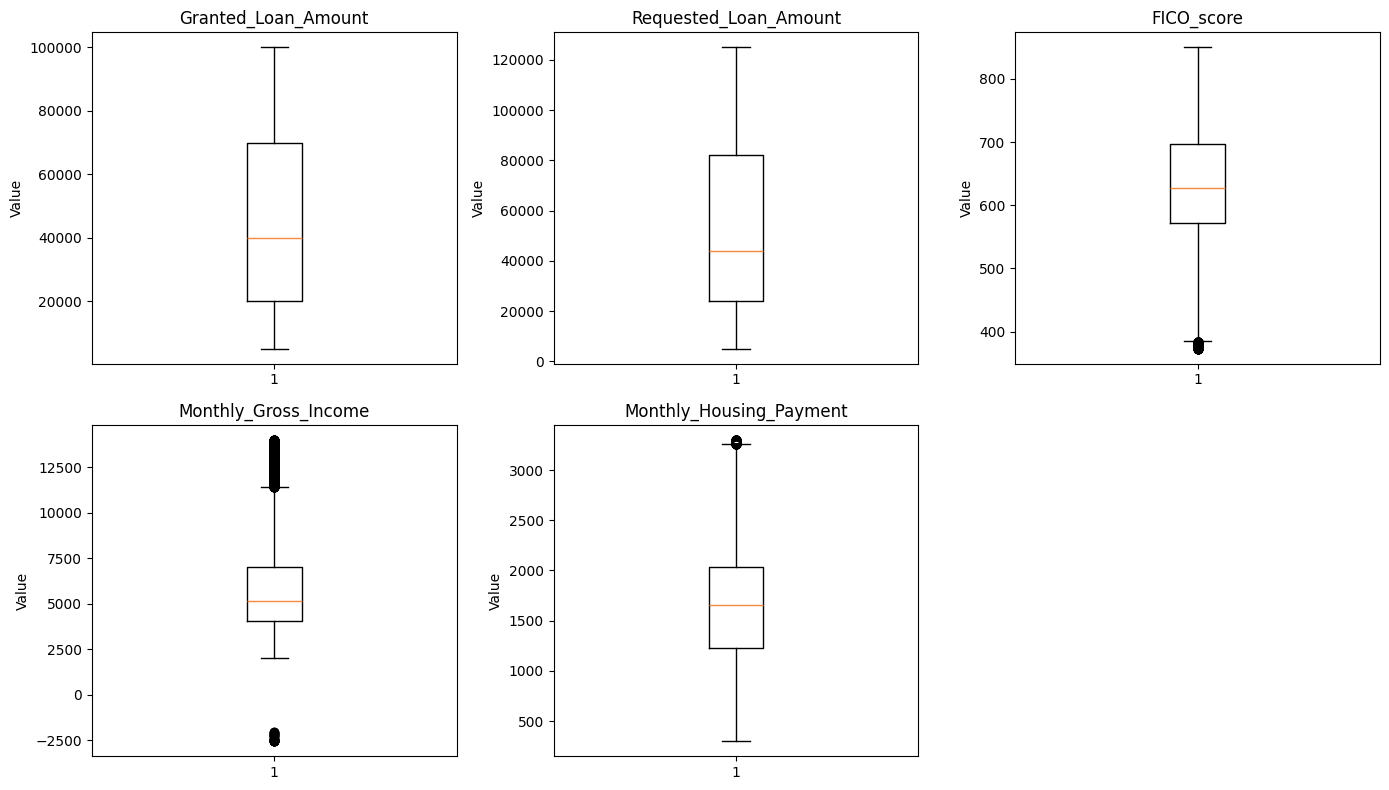

In [430]:
df# BoxPlots after outlier removal
plt.figure(figsize=(14, 8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_clean[col].dropna(), vert=True)
    plt.title(col)
    plt.ylabel('Value')

plt.tight_layout()
plt.show()


**Question:**
Why do we need to remove or treat outliers? Provide reasoning based on model performance or data integrity.

**Answer** : We need to remove outliers because they can negatively impact the model's performance. Including outliers can cause the data to become skewed and lead to inaccurate predictions.


**Question:**
Is there a difference between boxplots before and after outlier removal?

**Answer** : There is a massive difference in the boxplots before and after the outlier removal. The plots before removal showed many outliers that needed to be removed; the new boxplots are much more reasonable.

### 1.3 Redundancy & Correlation Check (5 Marks)

Detect duplicate data and multicollinearity.

**Question:**
Which numerical variables appear most strongly correlated with each other?

**Answer:** The numeric values that have the strongest correlation is the granted loan amount and the requested amount. This is because the granted loan requires that a loan amount was requested. Beyond that, the monthly gross income and the FICO score have a slight positive correlation with Accepted, the target variable.



**Question:**
Which numerical and categorical are strongly corelated to each other?

**Answer:** Based on the bottom heatmap, Monthly_Gross_Income is strongly correlated with Employment_Status, Fico_Score_group, and Employment_Sector. FICO_Score_Group is also very highly correlated to FICO_Score for obvious reasons.






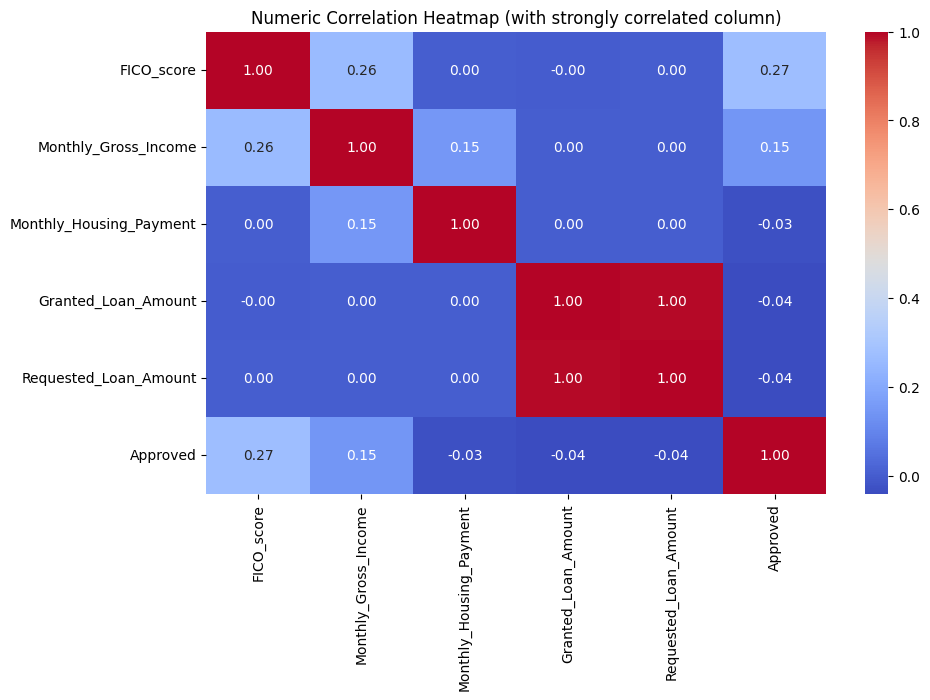

In [431]:
# Correlation between numerical features
numeric_cols = ['FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment', 'Granted_Loan_Amount','Requested_Loan_Amount', 'Approved']

# Plot correlation matrix, identify highly correlated pairs automatically (|corr|>0.95, excluding self-correlation)
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Numeric Correlation Heatmap (with strongly correlated column)")
plt.show()


/var/folders/rn/q5mhnl0s6cs970_0jwnlndpm0000gq/T/ipykernel_33416/1141312052.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()


Top 10 Numeric-Categorical Correlation Ratios (η²):
FICO_score - Fico_Score_group: η² = 0.866 (η = 0.931)
Monthly_Gross_Income - Employment_Status: η² = 0.245 (η = 0.495)
Monthly_Disposable_Income - Employment_Status: η² = 0.199 (η = 0.447)
Loan_to_Income_Ratio - Employment_Status: η² = 0.111 (η = 0.334)
DTI - Employment_Status: η² = 0.100 (η = 0.316)
Monthly_Disposable_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Gross_Income - Fico_Score_group: η² = 0.074 (η = 0.272)
Monthly_Gross_Income - Employment_Sector: η² = 0.070 (η = 0.265)
Monthly_Disposable_Income - Employment_Sector: η² = 0.062 (η = 0.249)
Monthly_Housing_Payment - Employment_Status: η² = 0.039 (η = 0.198)


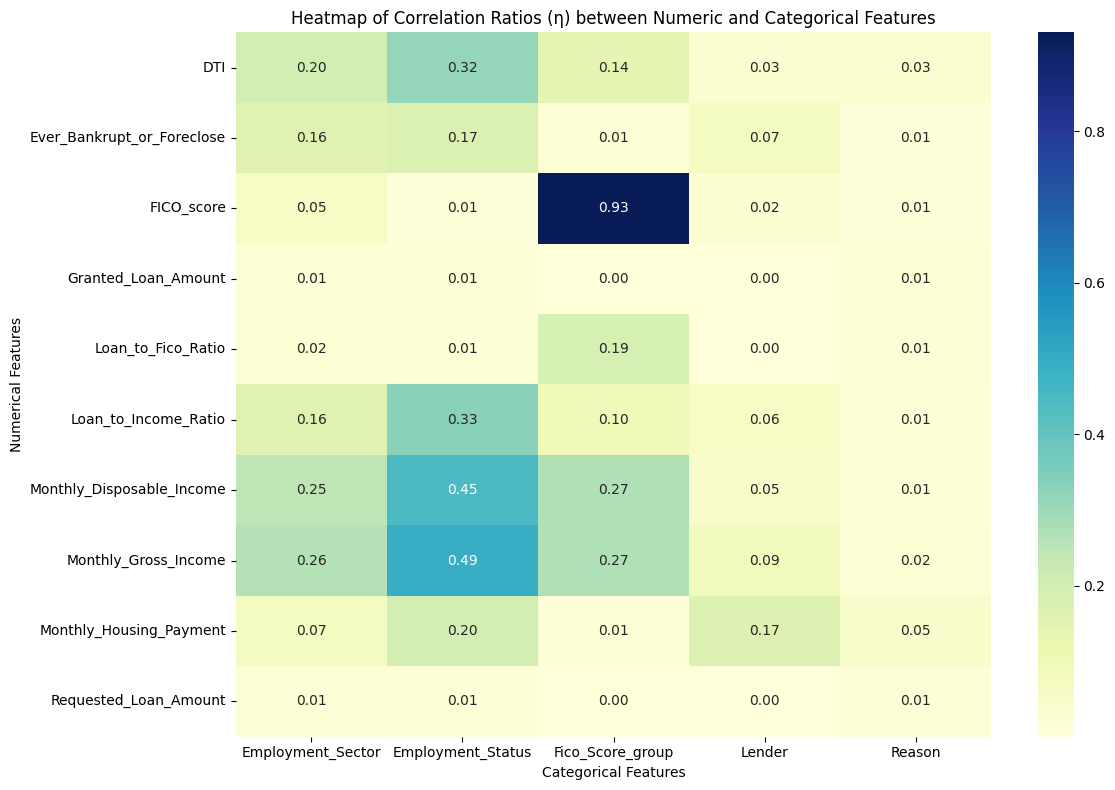

In [432]:
# Correlation between Numeric and Categorical Variables (Correlation Ratio / η²)

def correlation_ratio(categories, values):
    categories = np.array(categories)
    values = np.array(values)
    cat_levels = np.unique(categories)
    overall_mean = np.mean(values)
    numerator = sum(len(values[categories == cat]) *
                    (np.mean(values[categories == cat]) - overall_mean) ** 2
                    for cat in cat_levels)
    denominator = sum((values - overall_mean) ** 2)
    return np.sqrt(numerator / denominator) if denominator != 0 else 0

# test all numeric–categorical pairs
num_cat_results = []


# Identify categorical and numerical columns
categorical_cols_clean = df_clean.select_dtypes(include='object').columns.tolist()
numeric_cols_clean = df_clean.select_dtypes(include=np.number).columns.tolist()


numeric_cols_for_eta = [col for col in numeric_cols_clean if col not in ['bounty', 'Approved', ]]
categorical_cols_for_eta = [col for col in categorical_cols_clean]


for num_col in numeric_cols_for_eta:
    for cat_col in categorical_cols_for_eta:
        eta = correlation_ratio(df_clean[cat_col], df_clean[num_col])
        num_cat_results.append((num_col, cat_col, eta))

num_cat_results = sorted(num_cat_results, key=lambda x: x[2], reverse=True)
print("Top 10 Numeric-Categorical Correlation Ratios (η²):")
for num_col, cat_col, eta in num_cat_results[:10]:
    print(f"{num_col} - {cat_col}: η² = {eta**2:.3f} (η = {eta:.3f})")


# Reorganize the correlation ratio results into a pivot table/matrix for heatmap
eta_matrix = pd.DataFrame(num_cat_results, columns=['Numerical_Feature', 'Categorical_Feature', 'Eta'])
eta_pivot = eta_matrix.pivot(index='Numerical_Feature', columns='Categorical_Feature', values='Eta')

# Plot the heatmap of correlation ratios (Eta)
plt.figure(figsize=(12, 8))
sns.heatmap(eta_pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Heatmap of Correlation Ratios (η) between Numeric and Categorical Features")
plt.xlabel("Categorical Features")
plt.ylabel("Numerical Features")
plt.tight_layout()
plt.show()



**Questions:** What features will you consider dropping after analyzing the graphs above?

**Answer** : I will definitely drop the Granted_Loan_Amount due to leakage; there cannot be a granted amount if the loan is not approved, and thus would be a poor feature to include in the model. I will also drop the bounty feature for the same reason. Bounty only becomes "1" if the loan has been paid off. Lastly, I will also drop the Fico_Score_Group. Since FICO_Score is more specific, I want to keep that feature over the more generic score gorup.



> *Note: For Decision Tree models, you do not need to remove or adjust for collinearity. The algorithm can naturally handle correlated features through its splitting mechanism. However, for Logistic Regression, multicollinearity can distort coefficient estimates and make interpretations unreliable. In that case, you may consider removing one variable from highly correlated pairs.


## 2. Exploratory Data Analysis

### 2.1 Target Variable Distribution

Analyze the distribution of the target variable (Approved) to understand class balance in loan approval outcomes.


**Question:**
Is the dataset balanced or imbalanced? Briefly explain the implication for modeling.


**Answer:**
The data set is pretty imbalanced. As we can see from the below graph, 89% of the loan requests are denied.

/var/folders/rn/q5mhnl0s6cs970_0jwnlndpm0000gq/T/ipykernel_33416/1545037418.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Approved', palette='coolwarm')


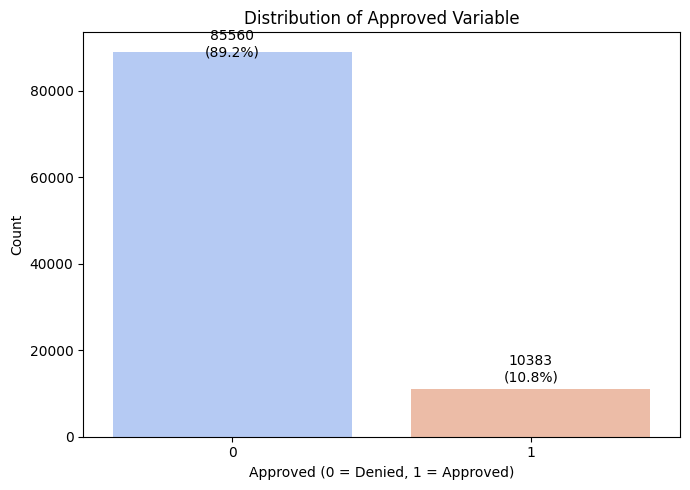

In [433]:
# Plot 'Approved' to visualise the count and balance
approved_counts = df_clean['Approved'].value_counts().sort_index()
approved_percent = df_clean['Approved'].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Approved', palette='coolwarm')
plt.title('Distribution of Approved Variable')
plt.xlabel('Approved (0 = Denied, 1 = Approved)')
plt.ylabel('Count')

for i, v in enumerate(approved_counts.values):
    ax.text(i, v + max(approved_counts.values) * 0.02, f'{v}\n({approved_percent.iloc[i]:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 Distribution of Numerical Variables by Approval

Explore how key numerical variables differ between approved and rejected loan applications.


**Question:**
Which numerical variable is the most helpful variable (most crucial predictor) ?

**Answer:**
Add your answer here


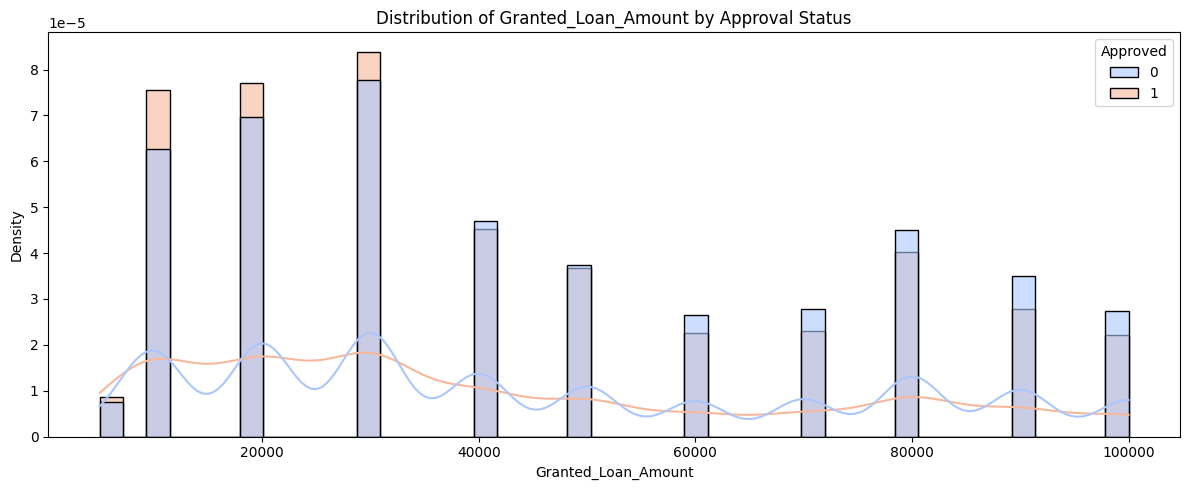

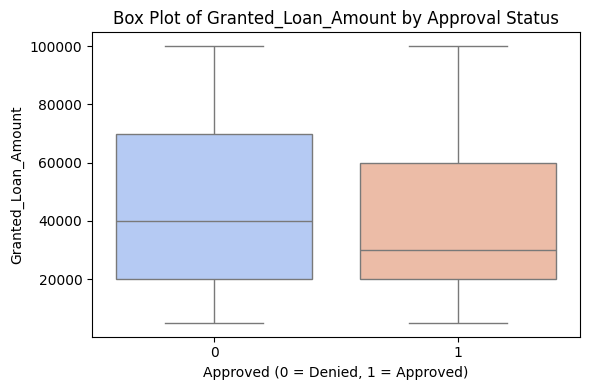

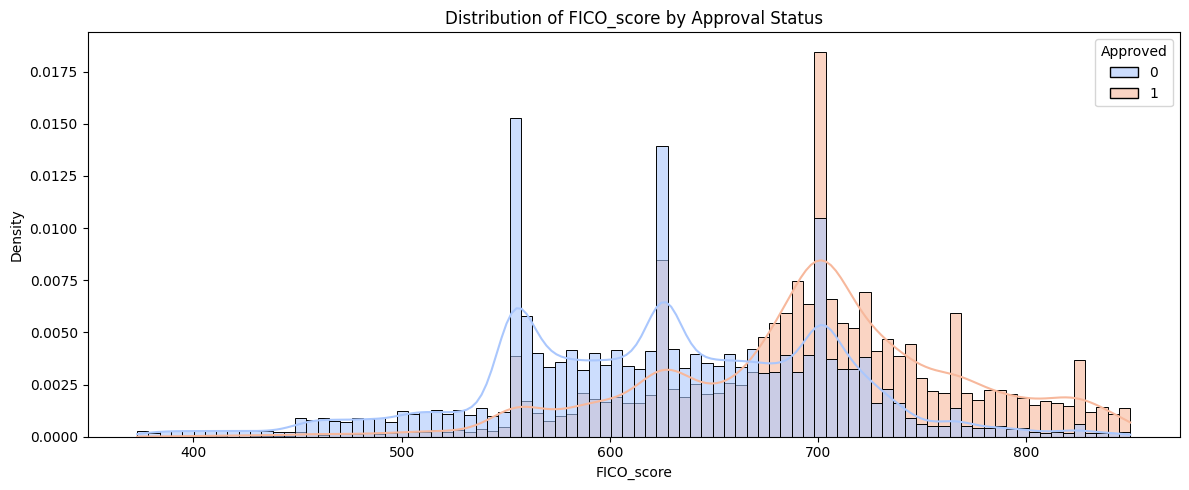

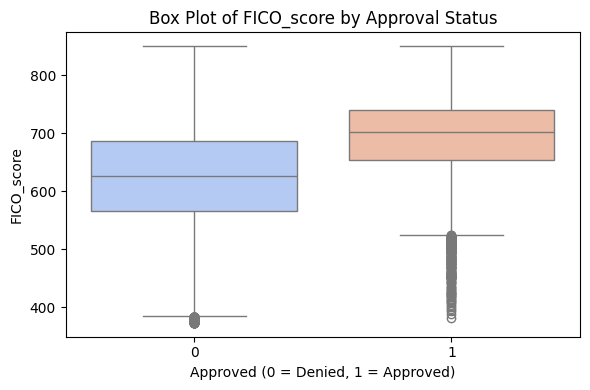

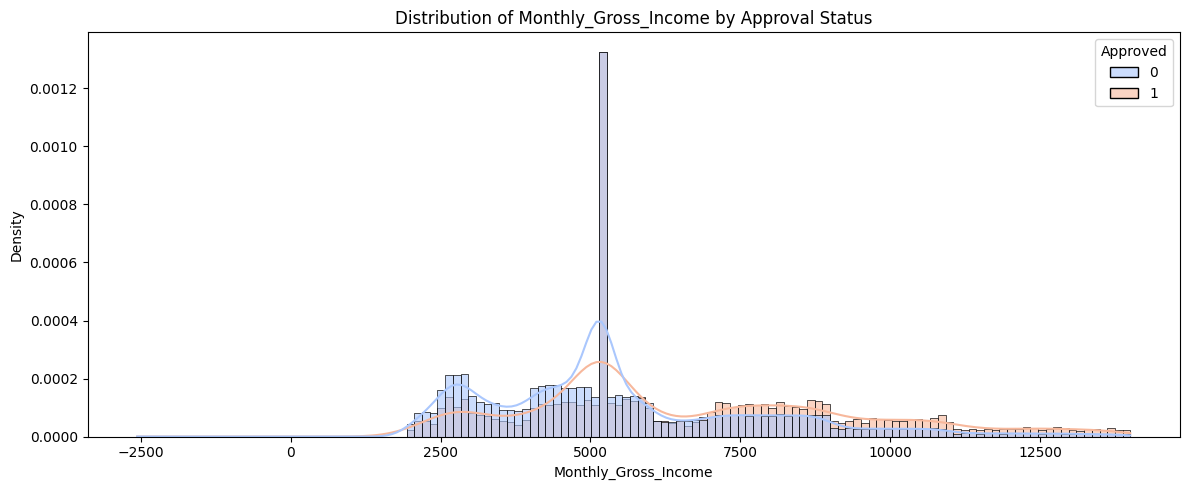

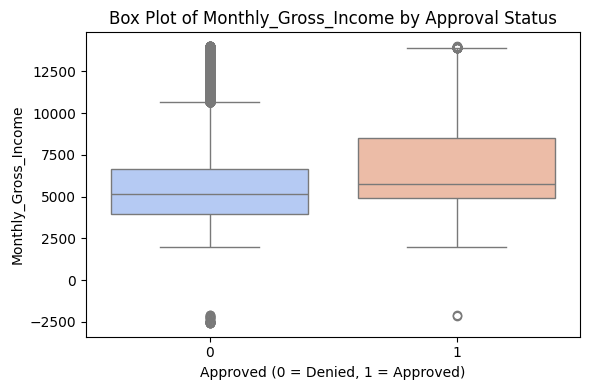

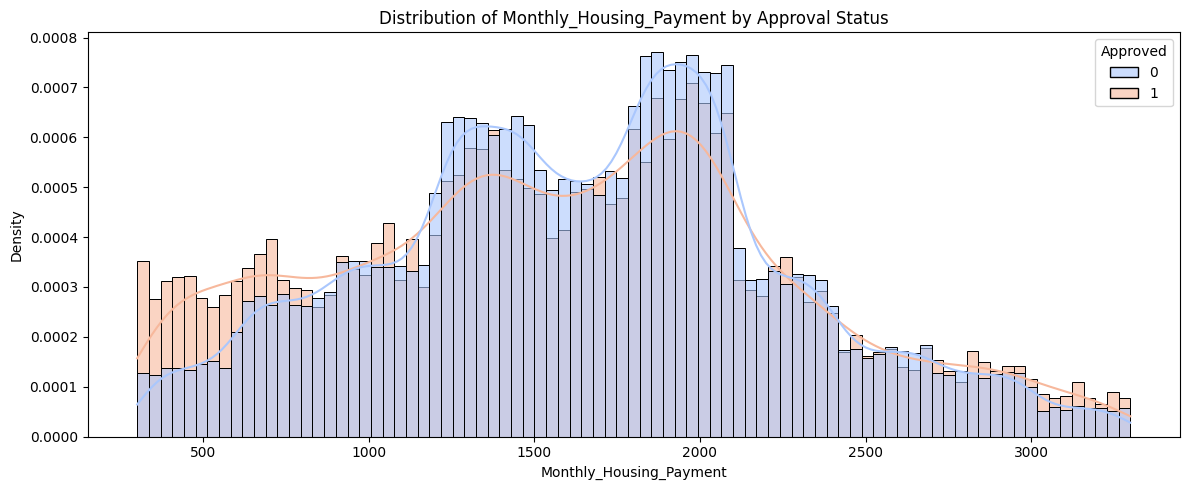

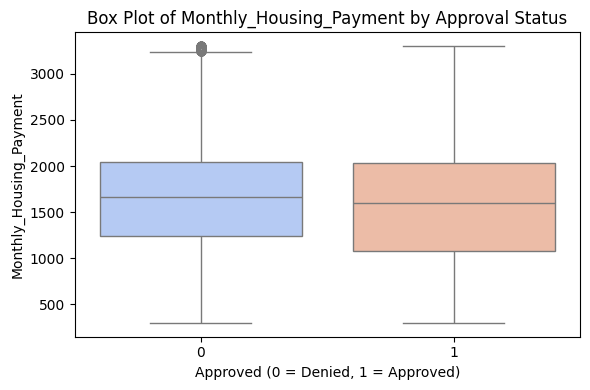

In [434]:
# Visualise numerical variables against target variable

numerical_cols = ['Granted_Loan_Amount', 'FICO_score', 'Monthly_Gross_Income', 'Monthly_Housing_Payment']

for col in numerical_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df_clean,
        x=col,
        hue='Approved',
        kde=True,
        stat='density',
        common_norm=False,
        palette='coolwarm',
        alpha=0.6
    )
    plt.title(f'Distribution of {col} by Approval Status')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df_clean,
        x='Approved',
        y=col,
        hue='Approved',
        palette='coolwarm',
        legend=False
    )
    plt.title(f'Box Plot of {col} by Approval Status')
    plt.xlabel('Approved (0 = Denied, 1 = Approved)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


### 2.3 Categorical Variables and Approval

Analyze how categorical variables (such as Employment_Sector, Loan_Purpose, or Residence_Type) relate to the loan approval outcome.


**Question:**
Which categorical variable appears to have the strongest relationship with loan approval, and how can you tell?

**Answer:**
Add your answer here


**Question:**
Are there any categories (e.g., Reason, Employment_Status) that appear to have minimal predictive value? Justify your answer with approval rate differences.

**Answer:**
Add your answer here

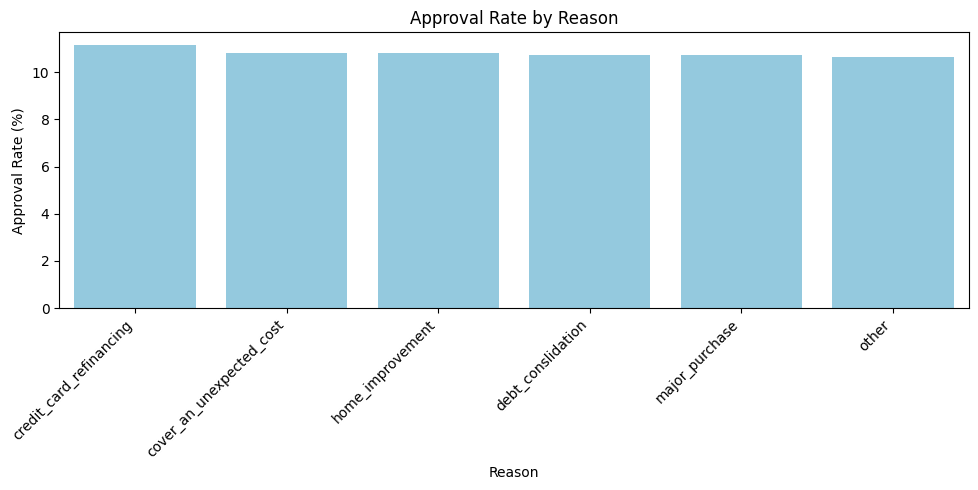


Approval Rate by Reason:
Reason
credit_card_refinancing     11.14
cover_an_unexpected_cost    10.82
home_improvement            10.80
debt_conslidation           10.75
major_purchase              10.72
other                       10.66
Name: Approved, dtype: float64


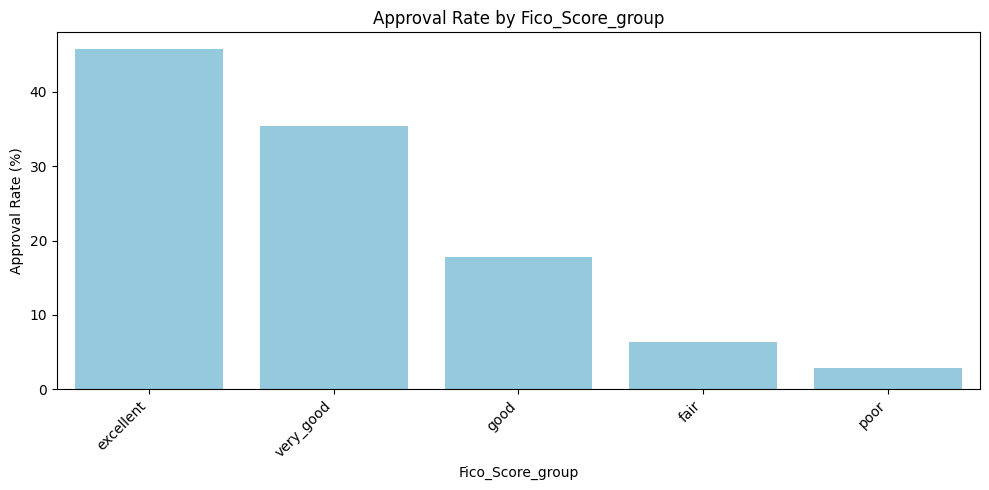


Approval Rate by Fico_Score_group:
Fico_Score_group
excellent    45.71
very_good    35.35
good         17.80
fair          6.37
poor          2.85
Name: Approved, dtype: float64


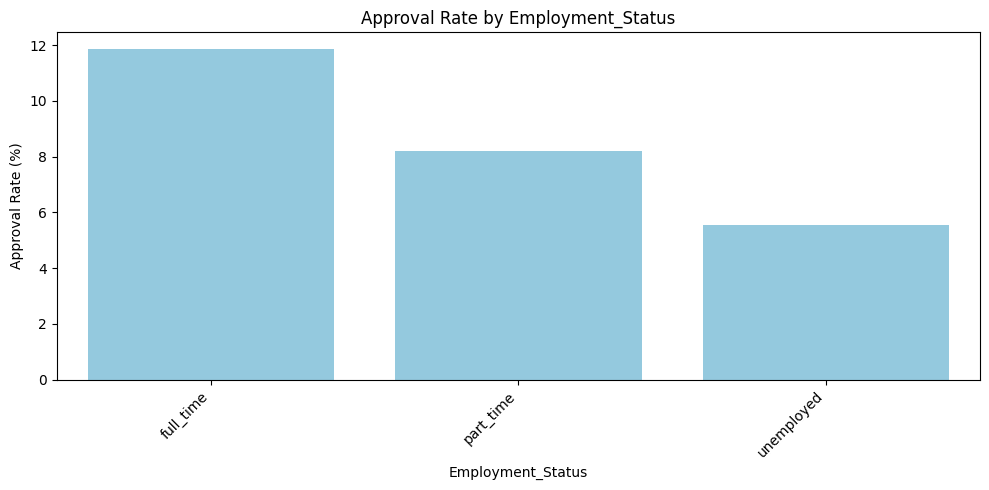


Approval Rate by Employment_Status:
Employment_Status
full_time     11.87
part_time      8.20
unemployed     5.54
Name: Approved, dtype: float64


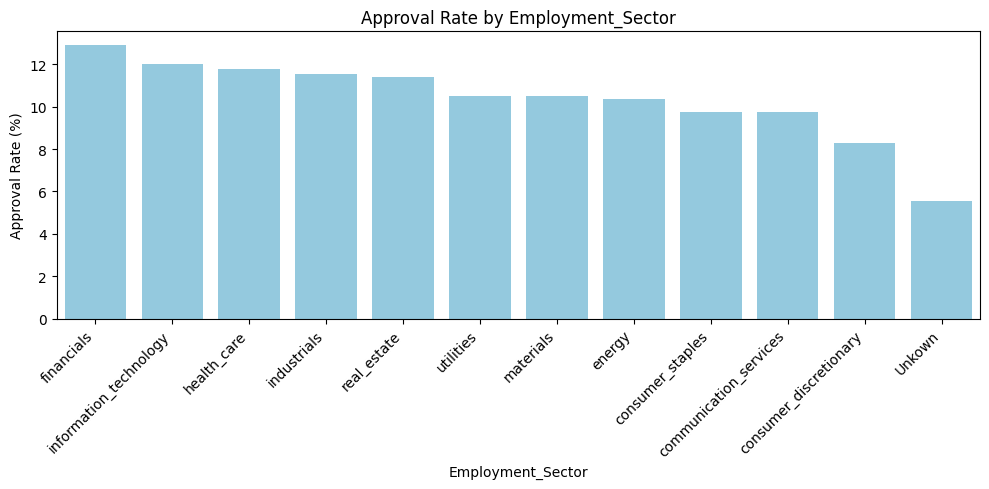


Approval Rate by Employment_Sector:
Employment_Sector
financials                12.91
information_technology    12.00
health_care               11.77
industrials               11.54
real_estate               11.41
utilities                 10.52
materials                 10.52
energy                    10.37
consumer_staples           9.77
communication_services     9.73
consumer_discretionary     8.29
Unkown                     5.54
Name: Approved, dtype: float64


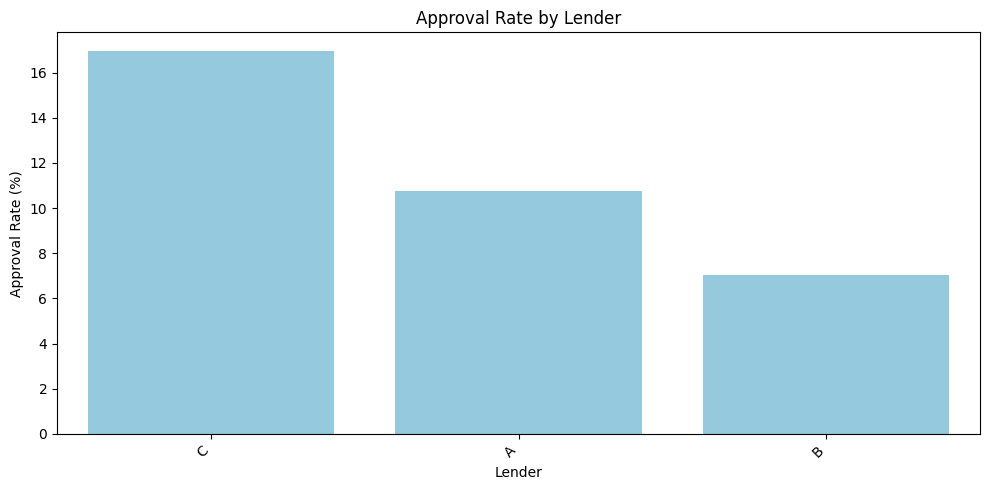


Approval Rate by Lender:
Lender
C    16.93
A    10.77
B     7.02
Name: Approved, dtype: float64


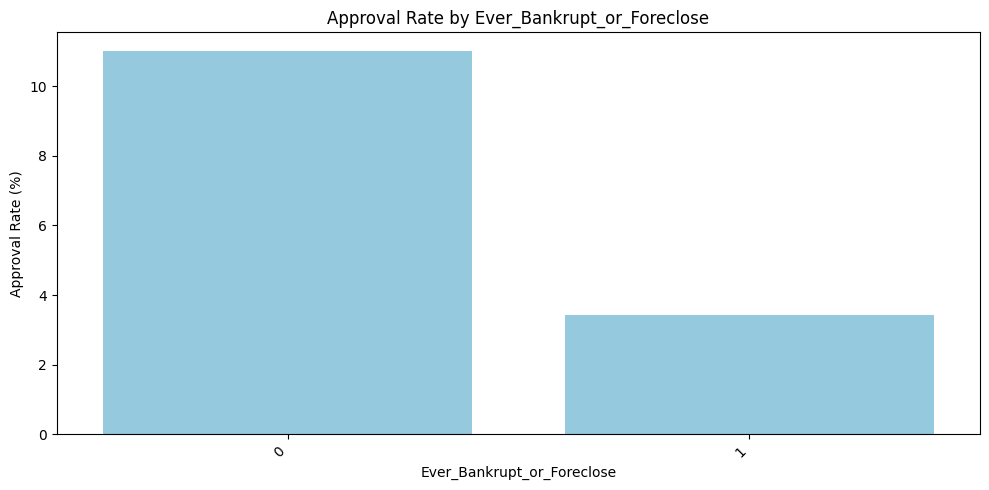


Approval Rate by Ever_Bankrupt_or_Foreclose:
Ever_Bankrupt_or_Foreclose
0    10.99
1     3.44
Name: Approved, dtype: float64


In [435]:
# Visualise categorical variables against target variable

categorical_cols = [
    'Reason', 'Fico_Score_group', 'Employment_Status',
    'Employment_Sector', 'Lender', 'Ever_Bankrupt_or_Foreclose'
]

for col in categorical_cols:
    approval_rates = df_clean.groupby(col)['Approved'].mean().sort_values(ascending=False) * 100

    plt.figure(figsize=(10,5))
    sns.barplot(x=approval_rates.index, y=approval_rates.values, color='skyblue')
    plt.title(f'Approval Rate by {col}')
    plt.xlabel(col)
    plt.ylabel('Approval Rate (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print(f"\nApproval Rate by {col}:\n{approval_rates.round(2)}")


### Cross Feature plots for multi-dimensional analysis.

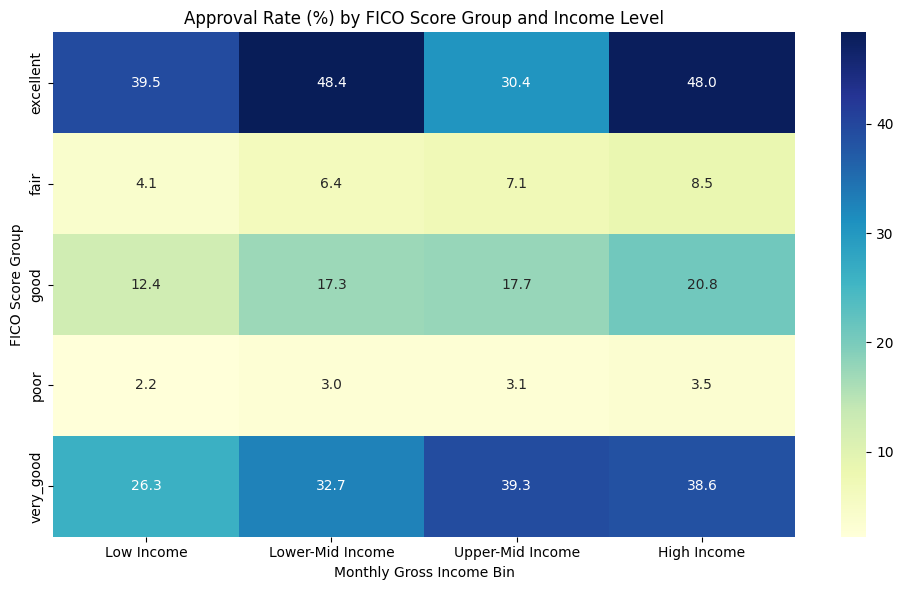

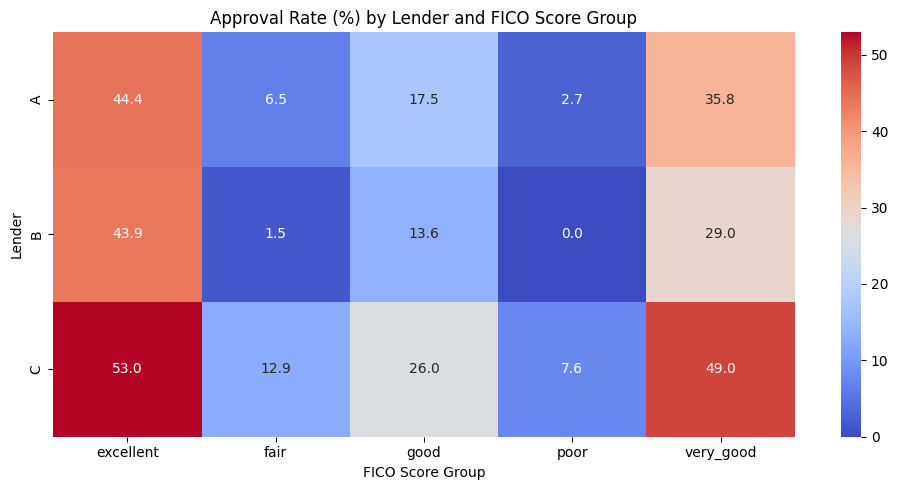

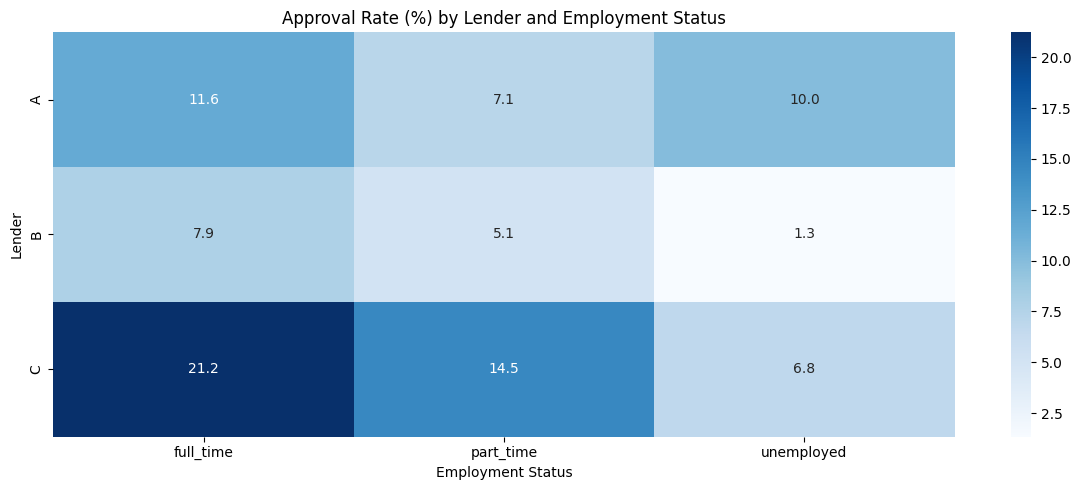

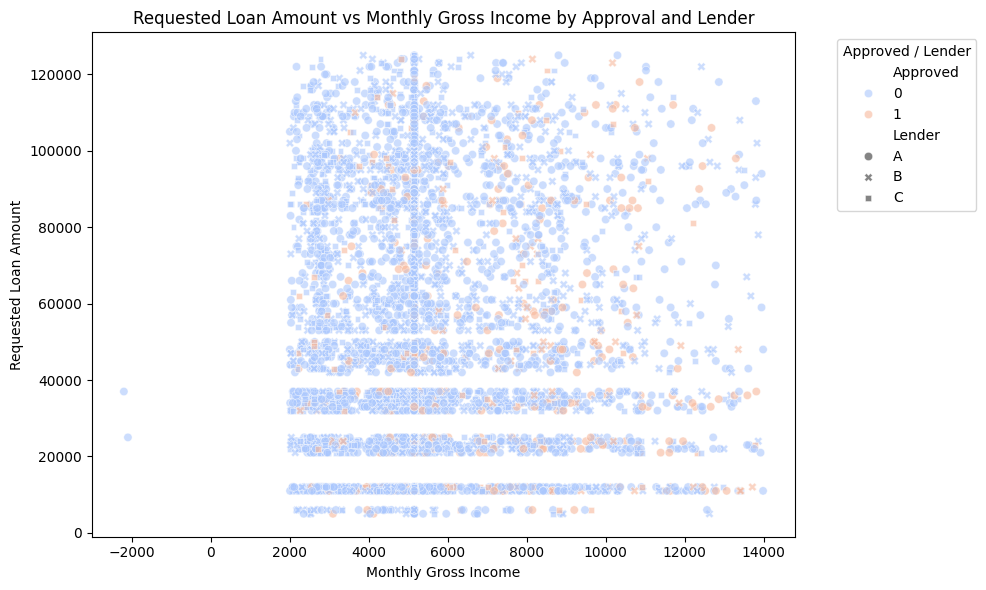

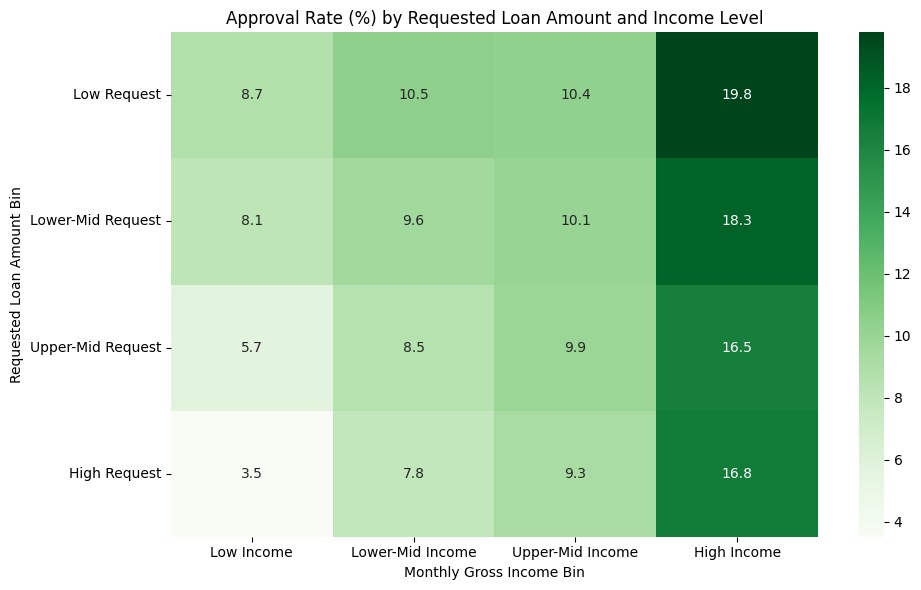

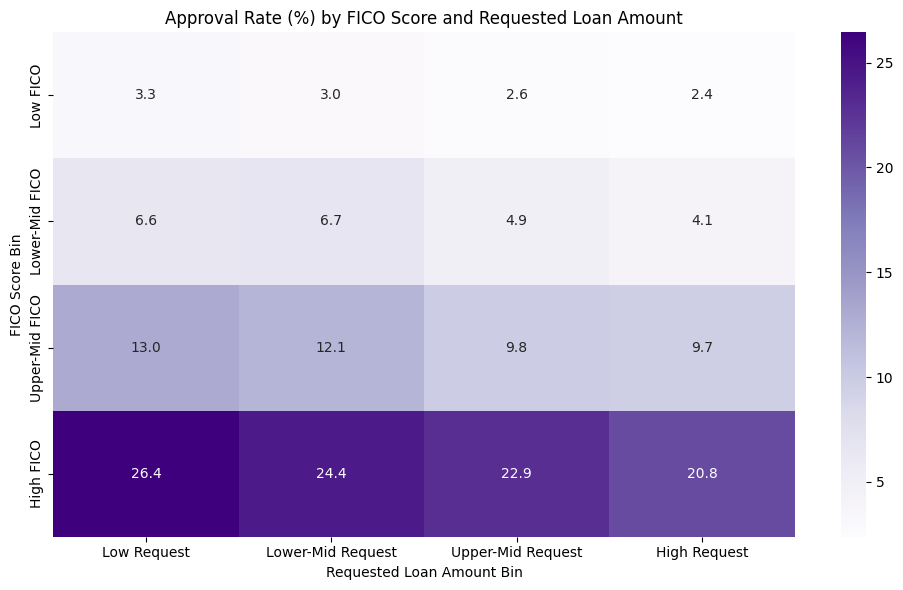

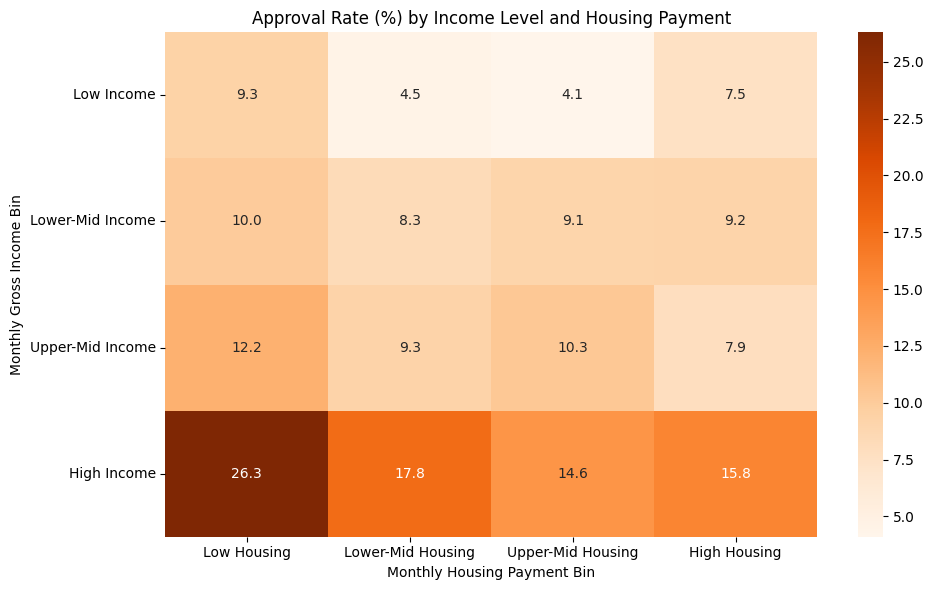

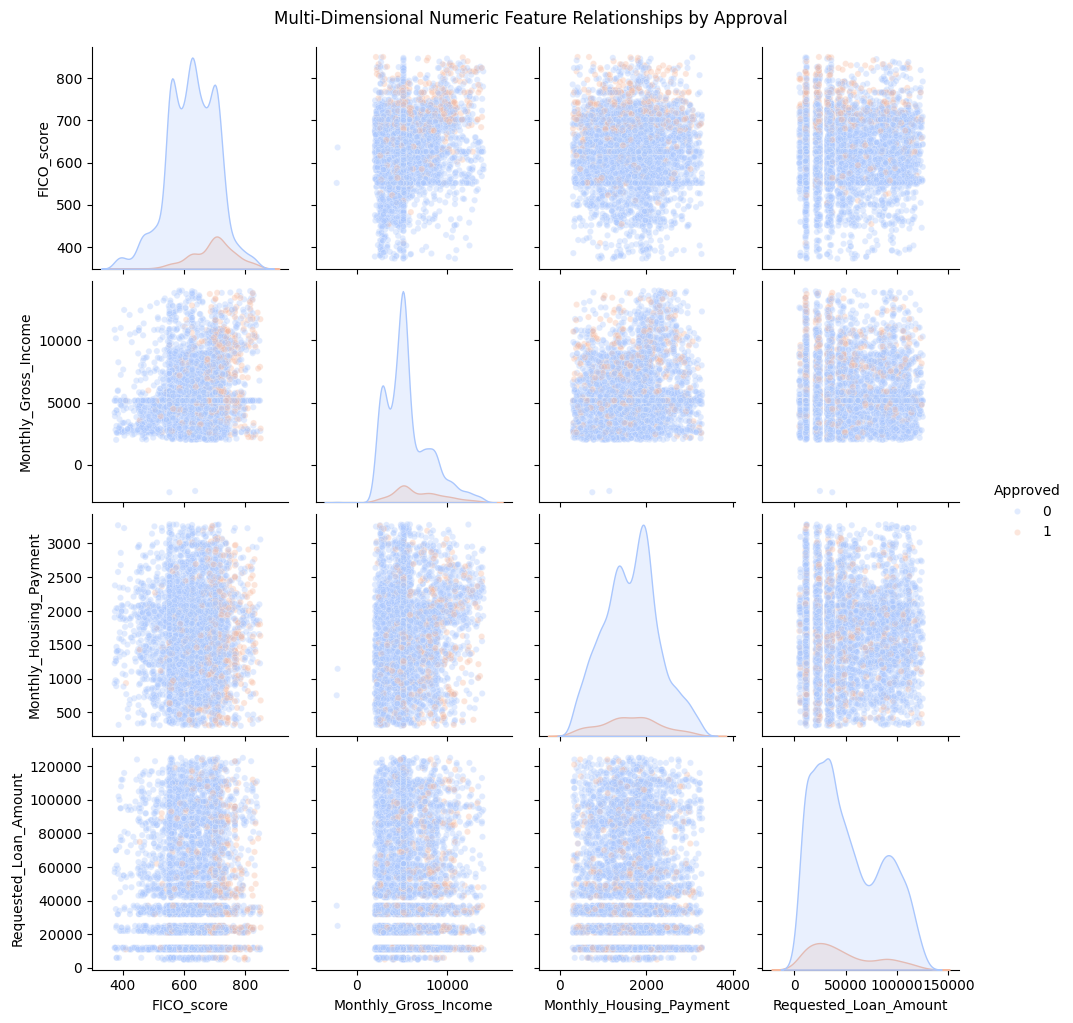

Approval Rate by FICO Score Group and Income Level (%):


Income_Bin,Low Income,Lower-Mid Income,Upper-Mid Income,High Income
Fico_Score_group,,,,
excellent,39.48,48.37,30.43,47.96
fair,4.15,6.37,7.13,8.49
good,12.39,17.30,17.65,20.84
poor,2.23,3.02,3.10,3.54
very_good,26.30,32.71,39.32,38.55


Approval Rate by Lender and FICO Score Group (%):


Fico_Score_group,excellent,fair,good,poor,very_good
Lender,,,,,
A,44.43,6.48,17.50,2.71,35.85
B,43.85,1.55,13.61,0.00,28.96
C,52.96,12.90,25.98,7.63,48.99


Approval Rate by Lender and Employment Status (%):


Employment_Status,full_time,part_time,unemployed
Lender,,,
A,11.63,7.09,9.99
B,7.87,5.08,1.34
C,21.23,14.53,6.75


Approval Rate by FICO Score and Requested Loan Amount (%):


Requested_Loan_Bin,Low Request,Lower-Mid Request,Upper-Mid Request,High Request
FICO_Bin,,,,
Low FICO,3.26,2.96,2.59,2.39
Lower-Mid FICO,6.61,6.67,4.92,4.10
Upper-Mid FICO,13.04,12.09,9.82,9.68
High FICO,26.44,24.38,22.94,20.82


Approval Rate by Income Level and Housing Payment (%):


Housing_Payment_Bin,Low Housing,Lower-Mid Housing,Upper-Mid Housing,High Housing
Income_Bin,,,,
Low Income,9.35,4.46,4.11,7.53
Lower-Mid Income,10.04,8.27,9.12,9.21
Upper-Mid Income,12.19,9.28,10.34,7.92
High Income,26.30,17.80,14.60,15.84


In [436]:
# Cross-feature plots for multi-dimensional analysis:

plot_df = df_clean.copy()

# Create interpretable bins for continuous variables
plot_df['Income_Bin'] = pd.qcut(
    plot_df['Monthly_Gross_Income'],
    q=4,
    labels=['Low Income', 'Lower-Mid Income', 'Upper-Mid Income', 'High Income']
)

plot_df['Requested_Loan_Bin'] = pd.qcut(
    plot_df['Requested_Loan_Amount'],
    q=4,
    labels=['Low Request', 'Lower-Mid Request', 'Upper-Mid Request', 'High Request']
)

plot_df['FICO_Bin'] = pd.qcut(
    plot_df['FICO_score'],
    q=4,
    labels=['Low FICO', 'Lower-Mid FICO', 'Upper-Mid FICO', 'High FICO']
)

plot_df['Housing_Payment_Bin'] = pd.qcut(
    plot_df['Monthly_Housing_Payment'],
    q=4,
    labels=['Low Housing', 'Lower-Mid Housing', 'Upper-Mid Housing', 'High Housing']
)

plot_df['Loan_to_Income_Ratio'] = (
        plot_df['Requested_Loan_Amount'] / plot_df['Monthly_Gross_Income']
).replace([np.inf, -np.inf], np.nan)

# 1. Approval rate by FICO score group and income level
fico_income_approval = plot_df.pivot_table(
    values='Approved',
    index='Fico_Score_group',
    columns='Income_Bin',
    aggfunc='mean',
    observed=False
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(fico_income_approval, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Approval Rate (%) by FICO Score Group and Income Level")
plt.xlabel("Monthly Gross Income Bin")
plt.ylabel("FICO Score Group")
plt.tight_layout()
plt.show()

# 2. Approval rate by lender and FICO score group
lender_fico_approval = plot_df.pivot_table(
    values='Approved',
    index='Lender',
    columns='Fico_Score_group',
    aggfunc='mean',
    observed=False
) * 100

plt.figure(figsize=(10, 5))
sns.heatmap(lender_fico_approval, annot=True, fmt=".1f", cmap="coolwarm")
plt.title("Approval Rate (%) by Lender and FICO Score Group")
plt.xlabel("FICO Score Group")
plt.ylabel("Lender")
plt.tight_layout()
plt.show()

# 3. Approval rate by lender and employment status
lender_employment_approval = plot_df.pivot_table(
    values='Approved',
    index='Lender',
    columns='Employment_Status',
    aggfunc='mean',
    observed=False
) * 100

plt.figure(figsize=(12, 5))
sns.heatmap(lender_employment_approval, annot=True, fmt=".1f", cmap="Blues")
plt.title("Approval Rate (%) by Lender and Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Lender")
plt.tight_layout()
plt.show()

# 4. Relationship between income, requested loan amount, approval, and lender
sample_df = plot_df.sample(n=min(5000, len(plot_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample_df,
    x='Monthly_Gross_Income',
    y='Requested_Loan_Amount',
    hue='Approved',
    style='Lender',
    palette='coolwarm',
    alpha=0.6
)
plt.title("Requested Loan Amount vs Monthly Gross Income by Approval and Lender")
plt.xlabel("Monthly Gross Income")
plt.ylabel("Requested Loan Amount")
plt.legend(title="Approved / Lender", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 5. Approval rate by requested loan amount and income level
request_income_approval = plot_df.pivot_table(
    values='Approved',
    index='Requested_Loan_Bin',
    columns='Income_Bin',
    aggfunc='mean',
    observed=False
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(request_income_approval, annot=True, fmt=".1f", cmap="Greens")
plt.title("Approval Rate (%) by Requested Loan Amount and Income Level")
plt.xlabel("Monthly Gross Income Bin")
plt.ylabel("Requested Loan Amount Bin")
plt.tight_layout()
plt.show()

# 6. Approval rate by numeric feature combinations
fico_request_approval = plot_df.pivot_table(
    values='Approved',
    index='FICO_Bin',
    columns='Requested_Loan_Bin',
    aggfunc='mean',
    observed=False
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(fico_request_approval, annot=True, fmt=".1f", cmap="Purples")
plt.title("Approval Rate (%) by FICO Score and Requested Loan Amount")
plt.xlabel("Requested Loan Amount Bin")
plt.ylabel("FICO Score Bin")
plt.tight_layout()
plt.show()

income_housing_approval = plot_df.pivot_table(
    values='Approved',
    index='Income_Bin',
    columns='Housing_Payment_Bin',
    aggfunc='mean',
    observed=False
) * 100

plt.figure(figsize=(10, 6))
sns.heatmap(income_housing_approval, annot=True, fmt=".1f", cmap="Oranges")
plt.title("Approval Rate (%) by Income Level and Housing Payment")
plt.xlabel("Monthly Housing Payment Bin")
plt.ylabel("Monthly Gross Income Bin")
plt.tight_layout()
plt.show()

# 7. Multi-dimensional numeric pairplot view
numeric_pairplot_cols = [
    'FICO_score',
    'Monthly_Gross_Income',
    'Monthly_Housing_Payment',
    'Requested_Loan_Amount',
    'Approved'
]

sns.pairplot(
    sample_df[numeric_pairplot_cols].dropna(),
    vars=[
        'FICO_score',
        'Monthly_Gross_Income',
        'Monthly_Housing_Payment',
        'Requested_Loan_Amount'
    ],
    hue='Approved',
    palette='coolwarm',
    diag_kind='kde',
    plot_kws={'alpha': 0.35, 's': 20}
)
plt.suptitle("Multi-Dimensional Numeric Feature Relationships by Approval", y=1.02)
plt.show()

# 8. Numeric feature correlation view by approval
numeric_analysis_cols = [
    'FICO_score',
    'Monthly_Gross_Income',
    'Monthly_Housing_Payment',
    'Requested_Loan_Amount',
    'Granted_Loan_Amount',
    'Loan_to_Income_Ratio',
    'Approved'
]


# Summary tables for business interpretation
print("Approval Rate by FICO Score Group and Income Level (%):")
display(fico_income_approval.round(2))

print("Approval Rate by Lender and FICO Score Group (%):")
display(lender_fico_approval.round(2))

print("Approval Rate by Lender and Employment Status (%):")
display(lender_employment_approval.round(2))

print("Approval Rate by FICO Score and Requested Loan Amount (%):")
display(fico_request_approval.round(2))

print("Approval Rate by Income Level and Housing Payment (%):")
display(income_housing_approval.round(2))


## 3.5 Business Insights from EDA

After completing your visualizations and cross-feature analyses, summarize your findings in the context of loan approval and lender matching.  
Use this section to connect data patterns to real-world meaning before building predictive models.


**Question:** Which variables are the most helpful in understanding if a customer is going to be approved or denied for a loan?  

**Answer**: The following variables are the most helpful in understanding if a customer is going to be approved or denied for a loan: Income Level, Employment Status, FICO Score Group, Monthly Gross Income, Employment Sector, and Ever_Bankrupt_or_Foreclose. 

**Question:** Are there any feature modifications or transformations that would improve the predictive power of a variable?  

**Answer**: I think the reason feature can be modified to be be a better predictor. Instead of having a single variable for every reason, I think it would be better if the reasons were grouped into categories. For example, credit_card_refinancing and debt_conslidation would be similar reasons for a loan and other ones like major_purchase or cover_an_unexpected_cost or something like that would be a different type of reason.

During training of my model, I noticed that instead of removing outlier values for certain features, I could instead take the log of those features to include them in the model without heavily skewing the model. I included this in my model training code, however, results were disappointing.

Upon training my decision tree, I saw that my model sucked – Again. I looked at the features again and realized I can create some more features that would be more useful for both models.

    * Debt to Income Ratio
    * Loan to Income Ratio
    * Monthly Disposable Income (Gross Income-Housing Payment)
    * Loan to Fico Score Ratio

I updated the df to include these features and trained my model again.

**Question:** What is each lender’s average approval rate?  

**Answer**: Lender A: 10.7%  Lender B: 7.02%  Lender C: 16.93%

**Question:** Are there any clear differences between the three lenders in terms of which types of customers they approve?  

**Answer**: It seems like Lender C seems to accept the most low-risk customers. Lender C has the highest approval rate for people that are employed full time, have high income, and have high credit scores. Lender B, on the other hand, tends to accept high-risk customers with low credit scores and income. Lender A is the middle ground of the two. 

**Question:** Are there variables that reliably predict a customer’s approval likelihood for a particular lender?  

**Answer**: As previously alluded to, having a high FICO score is a strong predictor of approval for Lender C, and inversely a low FICO score is a strong predictor of approval for Lender A. However, I do not know if those are "reliable" predictors.



> Treat this section as your interpretation bridge between EDA and modeling. The goal is to show that you understand *why* certain patterns exist, not just that they exist.


## 3. Model Training

### 3.1 Train/Test Split and Encoding

In [437]:
# Split dataset into train and test
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Rename your df to df_model.

df_model = df_clean.copy()

df_logged_model = df_logged.copy()

# We have to drop target variable and corelated variables
X = df_model.drop(columns=['Approved', 'bounty','Fico_Score_group','Lender','Granted_Loan_Amount'])

X_logged = df_logged_model.drop(columns=['Approved', 'bounty','Fico_Score_group','Lender','Granted_Loan_Amount'])


# Encode categorical features
# Add your code here
cat_cols = [col for col in df_model.select_dtypes(exclude = np.number).columns]

cat_cols_logged = [col for col in df_logged_model.select_dtypes(exclude = np.number).columns]

df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded_logged = pd.get_dummies(df_logged_model, drop_first=True)

# Set RANDOM_STATE = 42 for reproducibility.
random_state = 42

# Add your code here
y = df_model['Approved']

y_logged = df_logged_model['Approved']

# Identify column types
categorical_features = X.select_dtypes(include=["object", "category","str"]).columns.tolist()
categorical_features_logged = X_logged.select_dtypes(include=["object", "category","str"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
numeric_features_logged = X_logged.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state,
    stratify=y
)

x_train_logged, x_test_logged, y_train_logged, y_test_logged = train_test_split(
    X_logged,
    y_logged,
    test_size=0.2,
    random_state=random_state,
    stratify=y_logged
)
# Preprocessing:
# - scale numeric columns
# - one-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

### 3.2 Logistic Regression Model
Build and interpret a Logistic Regression model to predict the likelihood of loan approval (Approved = 1).

**Question**
How accurate is the model on the test data, and what does this imply about its predictive strength?

**Answer**
Both the logged and the outlier-removed (OR) model have about a 70% accuracy on their respective test sets. However, both models are not very good. The F1 scores for both models for the minority class (1) are in the mid 30s. This means that while it may have good recall (~0.74 for both), the precision is low for both (approximately 0.22 for both models). This means that, for both models, it blindly calls most entries a 1 when in reality, it is not. This being said, both models are okay, although they are not great when it comes to getting the prediction right. 


In [439]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            solver="liblinear",
            max_iter=5000,
            class_weight="balanced"
        ))
    ]
)

# 2. Set up the grid of parameters to test
# The "classifier__" prefix tells GridSearch to apply these to the classifier step
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__l1_ratio": [0, 1],
}

# 3. Create the GridSearchCV object
grid_search_model = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",  # Optimizing for f1 – A balance of recall and precision
    cv=3,
    n_jobs=1
)

#4. Create Gridsearch Log Object
grid_search_model_logged = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="f1",  # Optimizing for f1
    cv=3,
    n_jobs=1
)

# Train final model on the full training set
grid_search_model.fit(X_train, y_train)
grid_search_model_logged.fit(x_train_logged, y_train_logged)

# Get the raw probabilities for Class 1 (Approved)
y_pred = grid_search_model.predict(X_test)
y_pred_log = grid_search_model_logged.predict(x_test_logged)


In [440]:
y_train_pred = grid_search_model.predict(X_train)
y_test_pred = grid_search_model.predict(X_test)

y_train_pred_log = grid_search_model_logged.predict(x_train_logged)
y_trest_pred_log = grid_search_model_logged.predict(x_test_logged)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

train_accuracy_log = accuracy_score(y_train_logged, y_train_pred_log)
test_accuracy_log = accuracy_score(y_test_logged, y_trest_pred_log)

print("Logistic Regression Accuracy Comparison")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Difference:     {train_accuracy - test_accuracy:.4f}")

accuracy_comparison = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy, test_accuracy]
})

display(accuracy_comparison)


print("Logistic Regression Accuracy Comparison(Logged Dataset)")
print(f"Train Accuracy: {train_accuracy_log:.4f}")
print(f"Test Accuracy:  {test_accuracy_log:.4f}")
print(f"Difference:     {train_accuracy_log - test_accuracy_log:.4f}")

accuracy_comparison_log = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Accuracy": [train_accuracy_log, test_accuracy_log]
})

display(accuracy_comparison_log)


Logistic Regression Accuracy Comparison
Train Accuracy: 0.6830
Test Accuracy:  0.6852
Difference:     -0.0022


,Dataset,Accuracy
0,Train,0.682987
1,Test,0.685184


Logistic Regression Accuracy Comparison(Logged Dataset)
Train Accuracy: 0.6897
Test Accuracy:  0.6854
Difference:     0.0044


,Dataset,Accuracy
0,Train,0.68975
1,Test,0.68535


In [441]:
log_reg_feature_names = grid_search_model.best_estimator_.named_steps["preprocessor"].get_feature_names_out()
log_reg_coefficients = grid_search_model.best_estimator_.named_steps["classifier"].coef_[0]

log_reg_log_odds = pd.DataFrame({
    "Feature": log_reg_feature_names,
    "Log_Odds_Ratio": log_reg_coefficients,
    "Odds_Ratio": np.exp(log_reg_coefficients)
})

log_reg_log_odds = log_reg_log_odds[
    log_reg_log_odds["Log_Odds_Ratio"] != 0
    ].sort_values(by="Log_Odds_Ratio", ascending=False)

log_reg_logged_feature_names = grid_search_model_logged.best_estimator_.named_steps[
    "preprocessor"].get_feature_names_out()
log_reg_logged_coefficients = grid_search_model_logged.best_estimator_.named_steps["classifier"].coef_[0]

log_reg_logged_log_odds = pd.DataFrame({
    "Feature": log_reg_logged_feature_names,
    "Log_Odds_Ratio": log_reg_logged_coefficients,
    "Odds_Ratio": np.exp(log_reg_logged_coefficients)
})

log_reg_logged_log_odds = log_reg_logged_log_odds[
    log_reg_logged_log_odds["Log_Odds_Ratio"] != 0
    ].sort_values(by="Log_Odds_Ratio", ascending=False)

print("Log Odds Ratios for Logistic Regression Model:")
display(log_reg_log_odds)

print("Log Odds Ratios for Logged Logistic Regression Model:")
display(log_reg_logged_log_odds)


Log Odds Ratios for Logistic Regression Model:


,Feature,Log_Odds_Ratio,Odds_Ratio
1,num__FICO_score,0.946808,2.577468
7,num__Monthly_Disposable_Income,0.077797,1.080903
15,cat__Employment_Status_full_time,0.010250,1.010303
26,cat__Employment_Sector_information_technology,0.008129,1.008162
10,cat__Reason_credit_card_refinancing,0.001768,1.001770
21,cat__Employment_Sector_consumer_staples,-0.001086,0.998914
3,num__Monthly_Housing_Payment,-0.134467,0.874182
16,cat__Employment_Status_part_time,-0.153672,0.857553
4,num__Ever_Bankrupt_or_Foreclose,-0.160682,0.851563
17,cat__Employment_Status_unemployed,-0.237505,0.788593


Log Odds Ratios for Logged Logistic Regression Model:


,Feature,Log_Odds_Ratio,Odds_Ratio
1,num__FICO_score,0.999864,2.717912
2,num__Monthly_Gross_Income,0.254116,1.289322
8,num__Loan_to_Fico_Ratio,0.051359,1.052701
24,cat__Employment_Sector_health_care,0.016932,1.017076
4,num__Ever_Bankrupt_or_Foreclose,-0.146387,0.863823
0,num__Requested_Loan_Amount,-0.151984,0.859002
7,num__Monthly_Disposable_Income,-0.154460,0.856877
3,num__Monthly_Housing_Payment,-0.260939,0.770328
18,cat__Employment_Sector_Unkown,-0.275642,0.759085
16,cat__Employment_Status_part_time,-0.362759,0.695754


Metrics for Non-Logged Model:

Accuracy: 0.6851842201261139

Confusion Matrix:
[[11583  5529]
 [  512  1565]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.68      0.79     17112
           1       0.22      0.75      0.34      2077

    accuracy                           0.69     19189
   macro avg       0.59      0.72      0.57     19189
weighted avg       0.88      0.69      0.74     19189


ROC-AUC Score: 0.7757949102156952


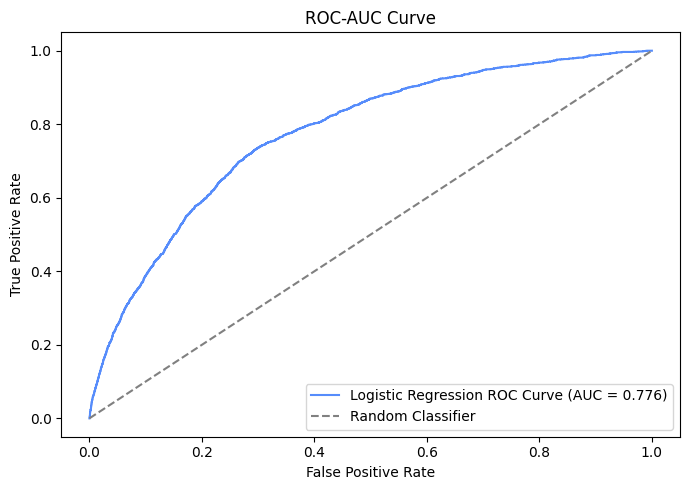

In [442]:
from sklearn.metrics import roc_curve, roc_auc_score

# Evaluate the Predictions
print("Metrics for Non-Logged Model:\n")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC-AUC Curve

y_probs = grid_search_model.predict_proba(X_test)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

print("\nROC-AUC Score:", roc_auc)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.tight_layout()
plt.show()


Metrics For Logged Model:

Accuracy: 0.68535

Confusion Matrix:
[[12076  5729]
 [  564  1631]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.68      0.79     17805
           1       0.22      0.74      0.34      2195

    accuracy                           0.69     20000
   macro avg       0.59      0.71      0.57     20000
weighted avg       0.87      0.69      0.74     20000



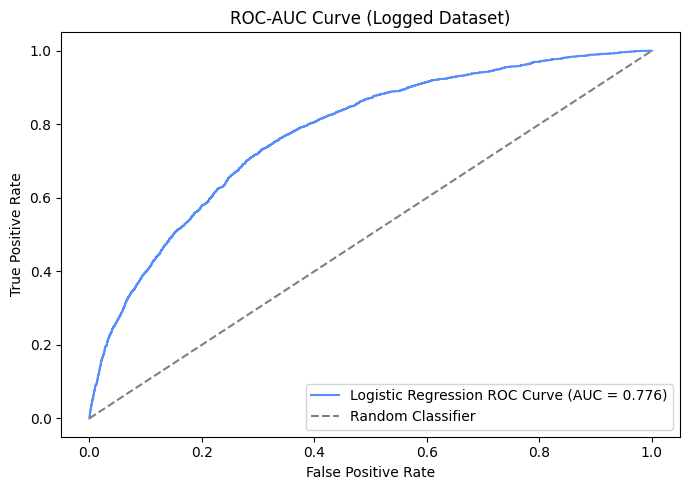

In [443]:

# Evaluate Predictions of Logged Model
print("Metrics For Logged Model:\n")
print("Accuracy:", accuracy_score(y_test_logged, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_logged, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test_logged, y_pred_log))

# ROC-AUC Curve

y_probs_log = grid_search_model_logged.predict_proba(x_test_logged)[:, 1]


fpr, tpr, thresholds = roc_curve(y_test_logged, y_probs_log)
roc_auc = roc_auc_score(y_test_logged, y_probs_log)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve (Logged Dataset)")
plt.legend()
plt.tight_layout()
plt.show()


### 3.2 Decision Tree Classifier Model

Build and interpret a Decision Tree Classifier Model to predict the likelihood of loan approval (Approved = 1).



**Question**
How does the Decision Tree’s accuracy and AUC compare to the Logistic Regression model?

**Answer**
Add your answer here


In [444]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Separate target from features
X = df_model.drop(columns=["Approved"])
y = df_model["Approved"]

# Preprocess categorical columns with OneHotEncoder
# Pass through only explicitly selected numeric columns
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ],
    remainder="drop"
)

# Build the Decision Tree pipeline
tree_pipeline_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=42,
            max_depth=5,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced"
        ))
    ]
)

# Create train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train the Decision Tree model
tree_pipeline_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

Decision Tree Train Accuracy: 0.700693123485421
Decision Tree Test Accuracy: 0.7014435353587993

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81     17112
           1       0.23      0.74      0.35      2077

    accuracy                           0.70     19189
   macro avg       0.59      0.72      0.58     19189
weighted avg       0.88      0.70      0.76     19189


Confusion Matrix:
[[11924  5188]
 [  541  1536]]

ROC-AUC Score: 0.5590


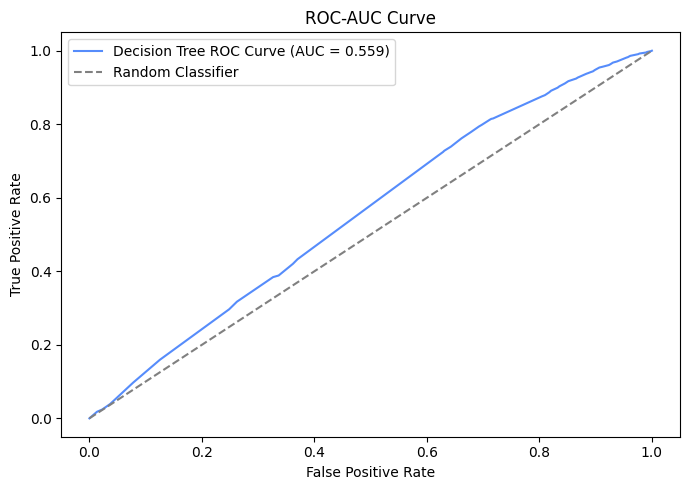

In [445]:
# Predict
tree_y_train_pred = tree_pipeline_model.predict(X_train)
tree_y_test_pred = tree_pipeline_model.predict(X_test)

# Evaluate
tree_train_accuracy = accuracy_score(y_train, tree_y_train_pred)
tree_test_accuracy = accuracy_score(y_test, tree_y_test_pred)

print("Decision Tree Train Accuracy:", tree_train_accuracy)
print("Decision Tree Test Accuracy:", tree_test_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, tree_y_test_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, tree_y_test_pred))


# ROC-AUC Curve Calculation
fpr, tpr, thresholds = roc_curve(y_test, tree_y_probs)
roc_auc = roc_auc_score(y_test, tree_y_probs)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Decision Tree ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()
plt.tight_layout()
plt.show()

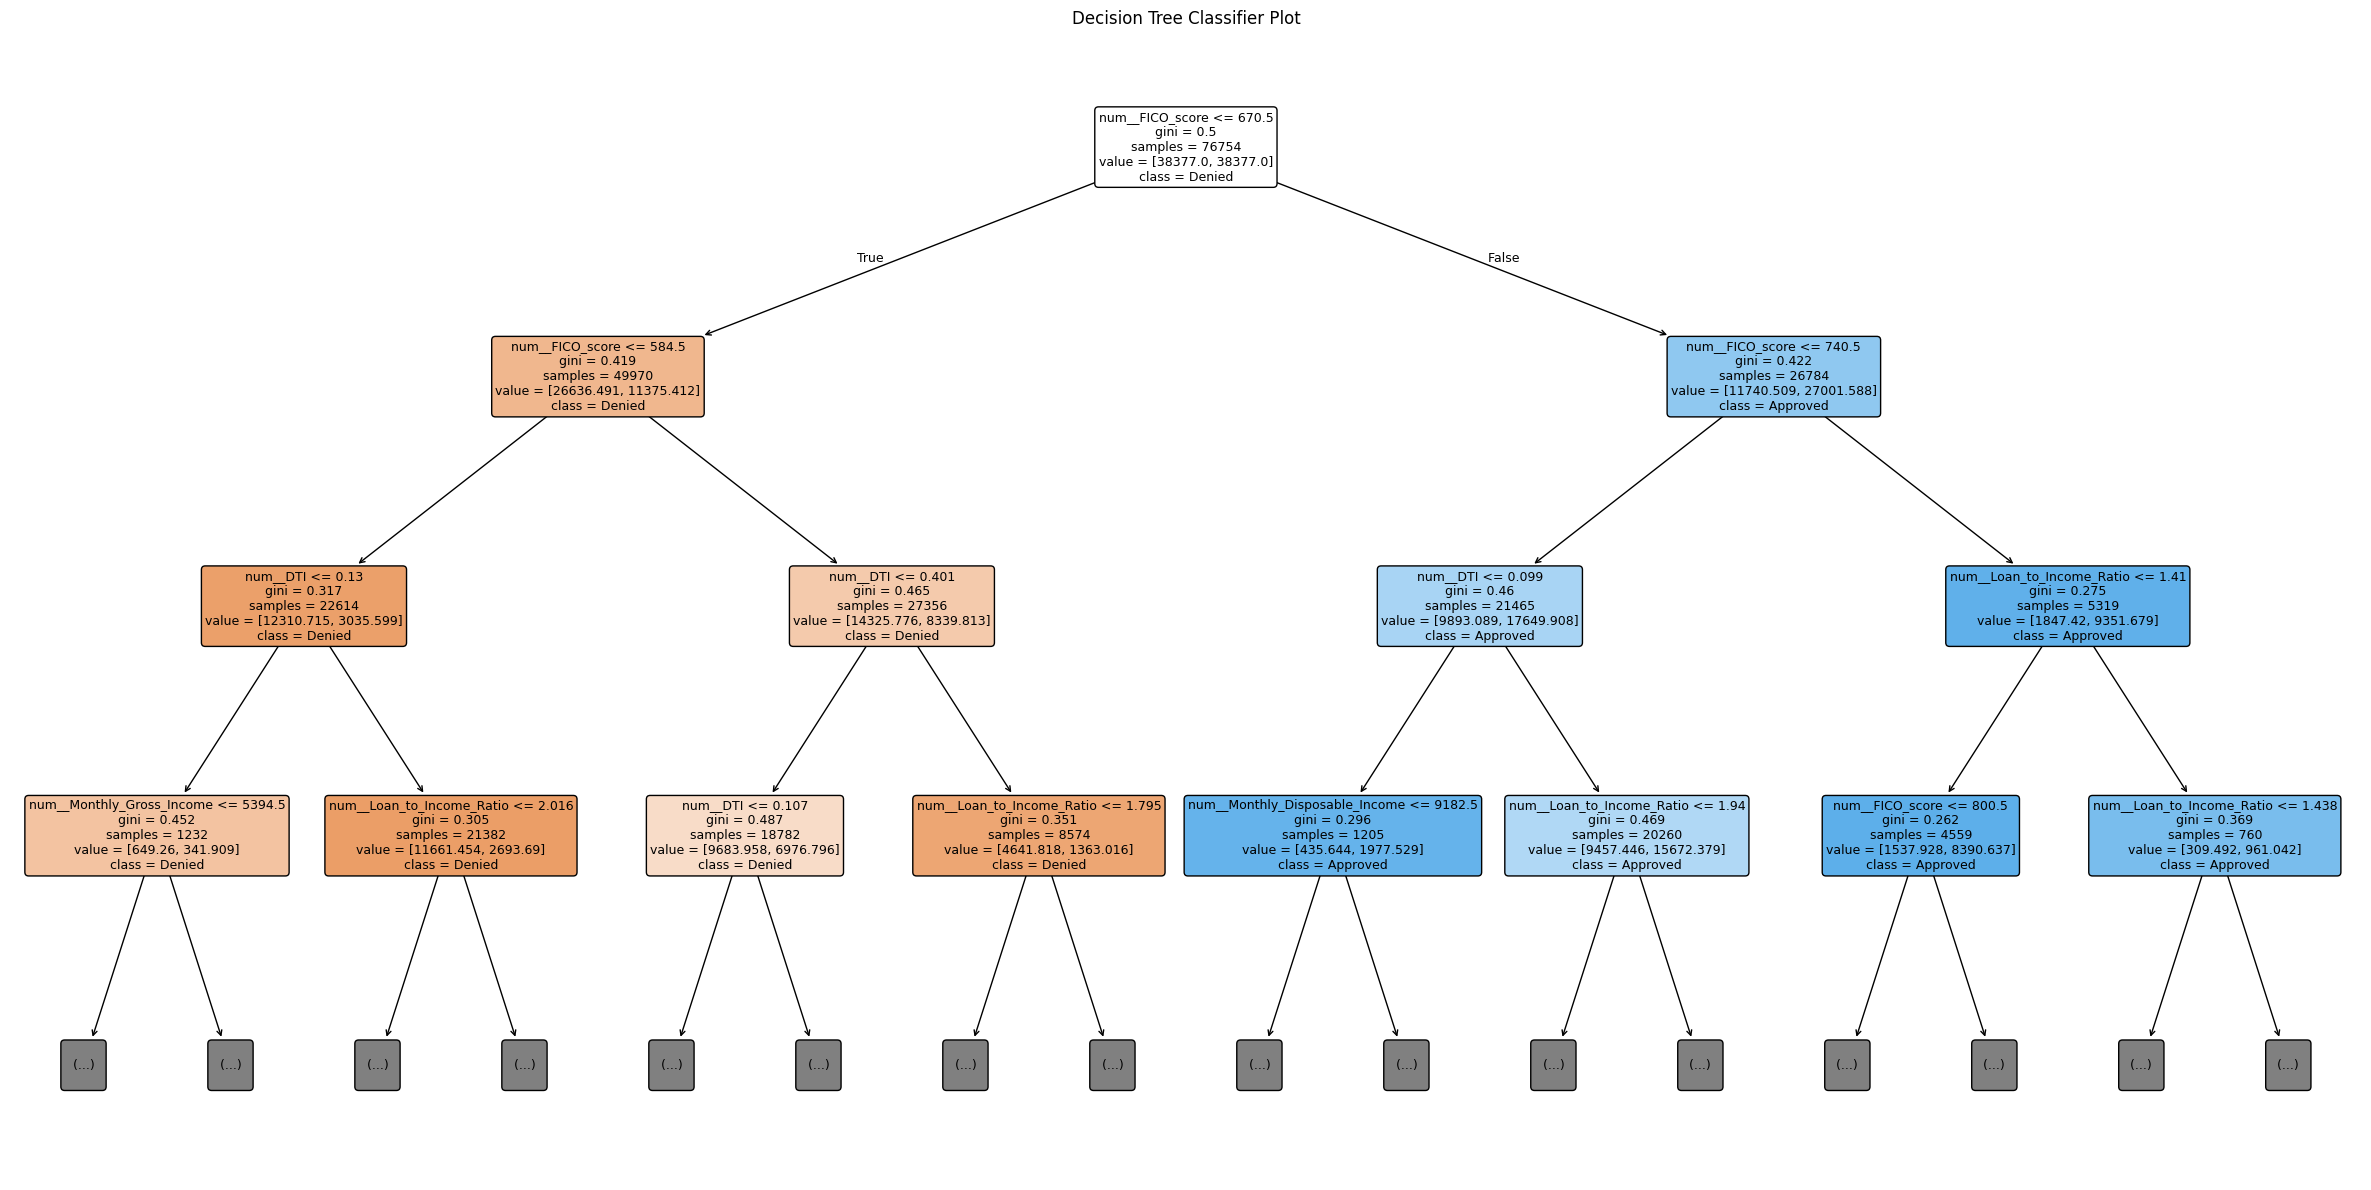

In [446]:
from sklearn.tree import plot_tree

# Plot the trained Decision Tree inside the pipeline
tree_classifier = tree_pipeline_model.named_steps["classifier"]
tree_feature_names = tree_pipeline_model.named_steps["preprocessor"].get_feature_names_out()

plt.figure(figsize=(24, 12))
plot_tree(
    tree_classifier,
    feature_names=tree_feature_names,
    class_names=["Denied", "Approved"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Classifier Plot")
plt.tight_layout()
plt.show()


In [447]:
# Variable importance for Decision Tree
# Print top features

tree_classifier = tree_pipeline_model.named_steps["classifier"]
tree_feature_names = tree_pipeline_model.named_steps["preprocessor"].get_feature_names_out()

tree_feature_importance = pd.DataFrame({
    "Feature": tree_feature_names,
    "Importance": tree_classifier.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Top 10 Decision Tree Features:")
display(tree_feature_importance.head(5))


Top 10 Decision Tree Features:


,Feature,Importance
22,num__FICO_score,0.835380
26,num__DTI,0.102455
27,num__Loan_to_Income_Ratio,0.033952
29,num__Loan_to_Fico_Ratio,0.010189
8,cat__Employment_Status_unemployed,0.006268


### Compare the performance of the Logistic Regression and Decision Tree models.


1.   Compare the performance of the Logistic Regression and Decision Tree
models.
2.   Evaluate and compare both models using key metrics such as ROC-AUC, Accuracy, Precision, Recall, and F1-score.
3. Plot and interpret the confusion matrices for both models. Discuss what false positives and false negatives mean in the business context (for example, approving risky applicants vs. rejecting qualified ones).

* False Positives mean approving someone who should not have been approved; a false negative means rejecting someone who should have been approved.

4. Identify which model best captures the target event (loan approval) and explain why.

* Based on the F1-score, recall, and precision, the Decision Tree model seems to be the best model. Although it isn't a traditionally good model (it tends to blindly accept people who shouldn't be accepted), it is still the better of the two models.

5. Justify your model choice from both technical (performance, interpretability) and business (actionability, trust, and decision-making) perspectives.

* The decision tree is the better performing model based on the recall, precision, and F1-score. Further, it is the easier to interpret of the two models. When it comes to the business aspect, it is easier to make decisions with the decision tree (go figure). It is easier to act on a decision tree because it gives you a "decision" (either a 1 or 0) based on a set of criterium.

6. Indicate the cutoff threshold you used and why it makes sense for this scenario.

* I used a cutoff threshold of 0.5 for both models. This was done so that the best threshold for balancing precision and recall. A higher threshold would have resulted in a noticeably lower recall, and a lower threshold would have resulted in a noticeably lower precision. Neither of which were great for the given scenario. Approving too many people means losing money due to unpaid loans. Not approving enough people means losing money due to less loans to collect interest on.

> Excluded the log logistic regression due to lack of major difference in performance from the outlier-excluded model

Model comparison using cutoff threshold = 0.5


,Model,ROC-AUC,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7758,0.6852,0.2206,0.7535,0.3413
1,Decision Tree,0.5590,0.7014,0.2284,0.7395,0.3491


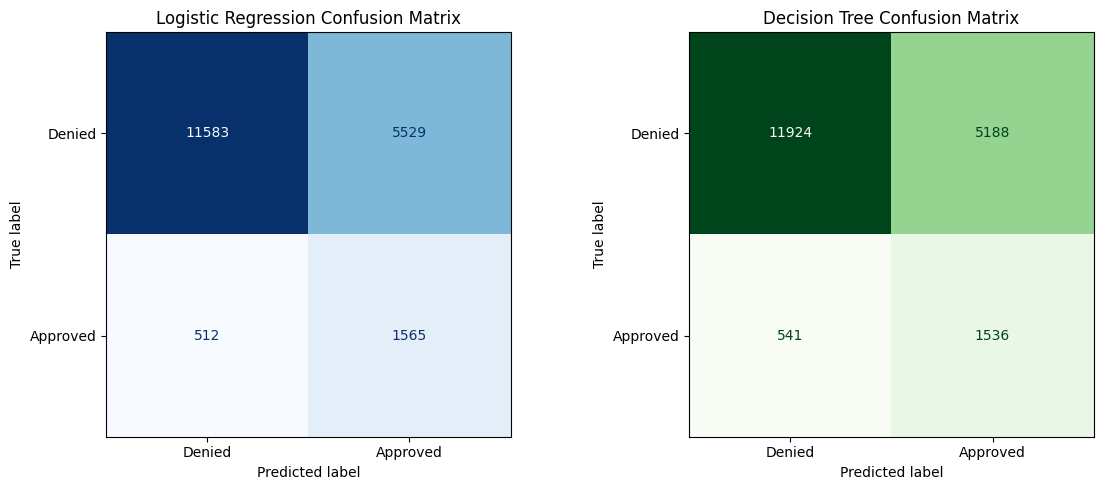

Best model based on F1-score for identifying loan approvals: Decision Tree


In [448]:
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

cutoff_threshold = 0.5

log_reg_y_pred = y_pred
log_reg_y_probs = y_probs

decision_tree_y_pred = tree_y_test_pred
decision_tree_y_probs = tree_y_probs

# Compare model performance
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "ROC-AUC": [
        roc_auc_score(y_test, log_reg_y_probs),
        roc_auc_score(y_test, decision_tree_y_probs)
    ],
    "Accuracy": [
        accuracy_score(y_test, log_reg_y_pred),
        accuracy_score(y_test, decision_tree_y_pred)
    ],
    "Precision": [
        precision_score(y_test, log_reg_y_pred, zero_division=0),
        precision_score(y_test, decision_tree_y_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, log_reg_y_pred, zero_division=0),
        recall_score(y_test, decision_tree_y_pred, zero_division=0)
    ],
    "F1-score": [
        f1_score(y_test, log_reg_y_pred, zero_division=0),
        f1_score(y_test, decision_tree_y_pred, zero_division=0)
    ]
})

print(f"Model comparison using cutoff threshold = {cutoff_threshold}")
display(model_comparison.round(4))

# Plot confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

log_reg_cm = confusion_matrix(y_test, log_reg_y_pred)
decision_tree_cm = confusion_matrix(y_test, decision_tree_y_pred)

ConfusionMatrixDisplay(
    confusion_matrix=log_reg_cm,
    display_labels=["Denied", "Approved"]
).plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)

axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=decision_tree_cm,
    display_labels=["Denied", "Approved"]
).plot(ax=axes[1], cmap="Greens", values_format="d", colorbar=False)

axes[1].set_title("Decision Tree Confusion Matrix")

plt.tight_layout()
plt.show()

best_model_name = model_comparison.sort_values(by="F1-score", ascending=False).iloc[0]["Model"]
print(f"Best model based on F1-score for identifying loan approvals: {best_model_name}")


**Question:**
Which model do you recommend and why? (Provide both technical and business reasoning.)

**Answer:** From both a performance and business standpoint, the decision tree is the better model to reccomend. The logistic regression has worse performance, and is harder to interpret from a business standpoint. The decision tree, by contrast, is both easier to understand and performs **slightly** better. If I was given more freedom in this project, I would attempt more models to see what was the best choice due to the relatively poor performance of both models.

In [449]:
model = tree_pipeline_model

In [450]:
# Save your model as .pkl file for streamlit app development
import pickle

filename = 'my_model.pkl'  # Choose a path and descriptive filename with .pkl extension

# Open the file in binary write mode ('wb')
with open(filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved successfully to {filename}")


Model saved successfully to my_model.pkl


## 4. Recommendations
In this final section, summarize your key findings and provide concise business recommendations based on your analysis.


**Write a short paragraph including:**  
- A brief summary of your main findings from the analysis and model comparison.  
- The key factors that most influence loan approval.  
- Your recommendations on data or model based on the results  (for example, how approval decisions could be improved or better understood).  
- One next step you would take to improve the model or extend the analysis further.  


**Add your paragraph here:**

From this analysis, I can conclude that the models I created are merely okay at predicting loan approvals. Both models suffer from high recall and low precision. This means that both models are saying "approved" when it shouldn't be. Unfortunately, I was not able to massively improve the models with no amount of hyperparameter tuning. With this in mind, I would like to try more models (namely XGBoost, Random Forests, and a Neural Network) to see if there's a better way to predict approvals. When it comes to loan approval, however, the decision tree was instrumental in telling us what factors are important. Namely, FICO_Score, Debt-to-Income Ratio, and Loan-to-Income ratio were the top 3 predictors of approval. According to the logistic regression, the features that most greatly affected the odds were the FICO score, monthly disposable income,  an unknown employment sector, and being a part-time employee.

---



**Question:**  What trade-offs or risks should the company be aware of when using this model?  

**Answer:** With this model, it is likely to approve someone when they shouldn't be. Another model or screening process should be used to ensure that the applicant is actually eligible for a loan. However, it is very good at predicting if someone should be denied (a 0.96 precision for 0's means that 96% of the denials from the model are true denials, which is very good).

**Question:** How confident are you in your model’s generalizability — what might change its performance in real-world use?   

**Answer:** When it comes to generalizability, I feel pretty confident in the model's performance. The reasoning behind this is that the model didn't overfit on the training data, as is shown by a low accuracy difference between test and train data. However, that is not to say that the model will perform well on new data given the fact that it doesn't perform well on the current data.


**Question:** If you had access to additional data, what new feature would you collect to strengthen this model?

**Answer:** I would collect more data that goes into credit reporting. Features like debt utilization, lines of credit, and net worth would likely benefit the performance of the model. These features, which go into FICO reporting, would help the models better figure out who is actually risky and better guess who is a risky individual.